# Setup


In [57]:
#Colab
# from google.colab import drive
# drive.mount('/content/drive')
# GNN_PATH = '/content/drive/MyDrive/Colab Notebooks/GNN/'

#Local
GNN_PATH = '../GNN_utilis/GNN/'
import os
if not os.path.exists(GNN_PATH):
    os.makedirs(GNN_PATH)

In [58]:
# Install packages
%pip install torch torch-geometric scikit-learn pandas shapely seaborn pygmtools numpy moviepy matplotlib optuna tensorboard
#check if pygmtools is installed
try:
    import pygmtools
except ImportError:#pygmtools library
    %pip install git+https://github.com/Thinklab-SJTU/pygmtools.git

# Check pytorch version and make sure you use a GPU Kernel
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
!nvcc --version
# Check GPU
!nvidia-smi

#set device as cuda if available to load model and data on gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.2.2+cpu
CUDA version: None




[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
"nvcc" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
"nvidia-smi" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [59]:

# ─── Standard library ──────────────────────────────────────────────────────────
import copy
import os
import sys
import pickle
import random
import time
import math
from pathlib import Path
from typing import List, Tuple, Dict, Any
from datetime import datetime

# ─── Third-party libraries ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.affinity import translate
from shapely.geometry import Polygon
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter


from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv, GCNConv

from moviepy.editor import ImageSequenceClip
from typing import Optional, Literal
import numpy as np
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import optuna
import json

# ─── Local application/library imports ────────────────────────────────────────
import pygmtools
pygmtools.BACKEND = 'pytorch'

destination_dir = os.path.join('AFAT')

# Ensure the destination directory is in sys.path
if destination_dir not in sys.path:
    sys.path.append(destination_dir)

# AFA-U inlier predictor and Top-K matching from AFAT
from k_pred_net import Encoder as AFAUEncoder
from sinkhorn_topk import soft_topk

In [60]:
# Set Seed for reproducibility
seed = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed once at the beginning
set_seed(seed)

# For reproducible DataLoader shuffle
g = torch.Generator()
g.manual_seed(seed)

#set device as cuda if available to load model and data on gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utilities

## Dataset

In [ ]:
#----------------------------------------
#            DATASET UTILS
#----------------------------------------

def deserialize_MSD_dataset(data_path, original_path=None, noise_path=None, dimensions_path=None):
    dataset_dir = Path(data_path)

    dimensions = []
    if dimensions_path is not None:
        # Load dimensions
        dimensions_file = dataset_dir / f"{dimensions_path}.pickle"
        if not dimensions_file.exists():
            raise FileNotFoundError(f"Dimensions file not found at {dimensions_file}")
        with open(dimensions_file, 'rb') as f:
            dimensions = pickle.load(f)

    # Clear existing graphs
    original = []
    noise = []

    if original_path is not None:
        original_dir = dataset_dir / original_path
        original_files = sorted(original_dir.glob("*.pt"), key=lambda f: int(f.stem))
        print(f"Loading {len(original_files)} original graphs...")
        for file in tqdm(original_files, desc="Original graphs"):
            with open(str(file), "rb") as f:
                graph = pickle.load(f)
                graph.graph['name'] = file.stem
            original.append(graph)

    if noise_path is not None:
        def extract_numeric_key(file):
            """Extracts (X, Y) from filenames like 'X_Y.pt' for proper numeric sorting."""
            name_parts = file.stem.split("_")
            return int(name_parts[0]), int(name_parts[1])

        noise_dir = dataset_dir / noise_path
        noise_files = sorted(noise_dir.glob("*.pt"), key=extract_numeric_key)
        print(f"Loading {len(noise_files)} noise graphs...")
        for file in tqdm(noise_files, desc="Noise graphs"):
            with open(str(file), "rb") as f:
                graph = pickle.load(f)
                graph.graph['name'] = file.stem
            noise.append(graph)

    return original, noise, dimensions

def serialize_graph_matching_dataset(pairs: List[Tuple[Data, Data, torch.Tensor]], path: str, filename: str = "train_dataset.pkl"):
    """
    Serialize a list of (Data1, Data2, PermutationMatrix) tuples to a file.
    """
    os.makedirs(path, exist_ok=True)
    full_path = os.path.join(path, filename)

    with open(full_path, 'wb') as f:
        pickle.dump(pairs, f)

    print(f"Serialized {len(pairs)} pairs to {full_path}")

def deserialize_graph_matching_dataset(path: str, filename: str = "train_dataset.pkl") -> List[Tuple[Data, Data, torch.Tensor]]:
    """
    Deserialize a dataset of (Data1, Data2, PermutationMatrix) tuples from a file.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File not found: {full_path}")

    with open(full_path, 'rb') as f:
        pairs = pickle.load(f)

    print(f"Loaded {len(pairs)} pairs from {full_path}")
    return pairs

def plot_a_graph(graphs_list, path=None, viz_rooms=True, viz_ws=True, viz_openings=False, viz_room_connection=True, viz_normals=False, viz_room_normals=False, viz_walls=True):
    """
    Visualizes geometries, wall segments, and graph edges for multiple apartments in 2D.

    Parameters:
    graphs_list (list of networkx.Graph): List of graphs with nodes ('type', 'center', 'normal') and edges for the apartments.
    viz_normals (bool): If True, plots wall segment normals.
    viz_rooms (bool): If True, displays room polygons.
    viz_ws (bool): If True, displays wall segments.
    viz_openings (bool): If True, displays openings (doors and windows).
    viz_wall_edges (bool): If True, displays edges between wall segments.
    viz_connection_edges (bool): If True, displays edges connecting rooms via openings.
    viz_walls (bool): If True, displays wall nodes and their edges.
    """
    _, ax = plt.subplots(1, 1, figsize=(10, 10))
    legend_added = False  # Flag to ensure the legend is added only once
    normal_added = False  # Flag to ensure the "Normal" label is added only once

    for graphs in graphs_list:
        # Visualize room polygons
        if viz_rooms:
            room_nodes = [n for n, d in graphs.nodes(data=True) if d['type'] == 'room']
            for idx, room_node in enumerate(room_nodes):
                room_data = graphs.nodes[room_node]
                # Plot the polygon
                room_polygon = Polygon(room_data['polygon'])
                x, y = room_polygon.exterior.xy
                ax.plot(x, y, color='black', alpha=0.2, label='Room polygon' if not legend_added and idx == 0 else "")
                # Draw room centroids
                ax.scatter(room_data['center'][0], room_data['center'][1], color='blue', s=100, label='Room centroid' if not legend_added and idx == 0 else "")

        # Visualize wall nodes and edges
        if viz_walls:
            wall_nodes = [n for n, d in graphs.nodes(data=True) if d['type'] == 'wall']
            for idx, wn in enumerate(wall_nodes):
                wall_data = graphs.nodes[wn]
                # Plot the polygon of the wall
                wall_polygon = Polygon(wall_data['polygon'])
                x, y = wall_polygon.exterior.xy
                ax.plot(x, y, color='purple', linestyle='-', label='Wall polygon' if not legend_added and idx == 0 else "")
                ax.scatter(wall_data['center'][0], wall_data['center'][1], color='purple', s=50, label='Wall centroid' if not legend_added and idx == 0 else "")

            if viz_normals:
                wall_ws = [n for n, d in graphs.nodes(data=True) if d['type'] == 'wall_ws']
                for idx, wn in enumerate(wall_ws):
                    ws_data = graphs.nodes[wn]
                    ax.scatter(ws_data['center'][0], ws_data['center'][1], color='purple', s=20, label='Wall ws' if not legend_added and idx == 0 else "")
                    ax.arrow(ws_data['center'][0], ws_data['center'][1],
                             ws_data['normal'][0], ws_data['normal'][1],
                             head_width=0.1, head_length=0.1, fc='green', ec='green', label='Normal' if not normal_added else "")
                    normal_added = True

            wall_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'wall' in u or 'wall' in v]
            for idx, edge in enumerate(wall_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                        [start_node['center'][1], end_node['center'][1]],
                        color='purple', linestyle='--', label='Wall edge' if not legend_added and idx == 0 else "")

        # Visualize openings
        if viz_openings:
            opening_nodes = [n for n, d in graphs.nodes(data=True) if 'door' in d['type'] or 'window' in d['type']]
            for idx, on in enumerate(opening_nodes):
                opening_data = graphs.nodes[on]
                opening_polygon = Polygon(opening_data['polygon'])
                x, y = opening_polygon.exterior.xy
                ax.plot(x, y, color='orange', label='Opening polygon' if not legend_added and idx == 0 else "")
                # Draw opening centroids
                ax.scatter(opening_data['center'][0], opening_data['center'][1], color='orange', s=10, label='Opening centroid' if not legend_added and idx == 0 else "")

            if viz_normals:
                opening_ws = [n for n, d in graphs.nodes(data=True) if d['type'] == 'door_ws' or d['type'] == 'window_ws']
                for idx, wn in enumerate(opening_ws):
                    ws_data = graphs.nodes[wn]
                    ax.scatter(ws_data['center'][0], ws_data['center'][1], color='orange', s=10, label='Opening ws' if not legend_added and idx == 0 else "")
                    ax.arrow(ws_data['center'][0], ws_data['center'][1],
                             ws_data['normal'][0], ws_data['normal'][1],
                             head_width=0.1, head_length=0.1, fc='green', ec='green', label='Normal' if not normal_added else "")
                    normal_added = True

            # Draw opening edges
            open_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'door' in u or 'window' in v or 'door' in v or 'window' in u]
            for idx, edge in enumerate(open_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                        [start_node['center'][1], end_node['center'][1]],
                        color='orange', linestyle='--', label='Opening edge' if not legend_added and idx == 0 else "")

        # Visualize ws room
        if viz_ws:
            ws_nodes = [n for n, d in graphs.nodes(data=True) if d['type'] == 'ws']
            for idx, wn in enumerate(ws_nodes):
                ws_data = graphs.nodes[wn]
                ax.scatter(ws_data['center'][0], ws_data['center'][1], color='red', s=20, label='Ws segment' if not legend_added and idx == 0 else "")
                if viz_room_normals:
                    ax.arrow(ws_data['center'][0], ws_data['center'][1],
                             ws_data['normal'][0], ws_data['normal'][1],
                             head_width=0.1, head_length=0.1, fc='green', ec='green', label='Normal' if not normal_added else "")
                    normal_added = True
                if 'limits' in ws_data:
                    limit_1, limit_2 = ws_data['limits']
                    ax.plot([limit_1[0], limit_2[0]],
                            [limit_1[1], limit_2[1]],
                            color='black', linewidth=1.0,
                            label='Ws limits' if idx == 0 else "")
            ws_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'ws_same_room' in d['type'] or 'ws_belongs_room' in d['type']]
            for idx, edge in enumerate(ws_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                    [start_node['center'][1], end_node['center'][1]],
                    color='gray', linestyle='--', label='Ws edge' if not legend_added and idx == 0 else "")

        # Visualize connection edges
        if viz_room_connection:
            connection_edges = [(u, v) for u, v, d in graphs.edges(data=True) if 'connected' in d['type']]
            for idx, edge in enumerate(connection_edges):
                start_node = graphs.nodes[edge[0]]
                end_node = graphs.nodes[edge[1]]
                ax.plot([start_node['center'][0], end_node['center'][0]],
                        [start_node['center'][1], end_node['center'][1]],
                        color='blue', linestyle='-', label='Connection edge' if not legend_added and idx == 0 else "")

        legend_added = True  # Set the flag to True after processing the first graph

    plt.title("Apartment Graph Visualization")
    plt.legend()
    if path is None:
        plt.show()
    else:
        plt.savefig(path)
        plt.close()

node_type_mapping = {"room": [1, 0], "ws": [0, 1]}

def pyg_data_to_nx_digraph(data: Data, graph_list: List[nx.DiGraph]) -> nx.DiGraph:
    """
    Convert a PyTorch Geometric Data object back to a NetworkX DiGraph,
    restoring original node IDs using data.node_names and data.permutation,
    matching with the graph in graph_list that has the same name.
    """
    assert hasattr(data, 'node_names'), \
        "Data object must contain 'node_names' to restore original node IDs."
    assert hasattr(data, 'permutation'), \
        "Data object must contain 'permutation' to reorder nodes."
    assert hasattr(data, 'name'), \
        "Data object must contain 'name' to match with graph_list."
    # All candidates with the same name
    candidates = [g for g in graph_list if g.graph.get('name') == data.name]

    if not candidates:
        raise ValueError(f"No graph with name {data.name} found in graph_list.")
    node_name_set = set(data.node_names)

    # Among the candidates, find the one whose nodes match exactly
    matching_graph = next(
        (g for g in candidates if set(g.nodes()) == node_name_set),
        None
    )
    # Fallback: the candidate with the highest coverage
    if matching_graph is None:
        matching_graph = max(candidates, key=lambda g: len(node_name_set & set(g.nodes())))

    orig_names = data.node_names
    perm = data.permutation.tolist()
    node_ids = [orig_names[idx] for idx in perm]
    G = nx.DiGraph()
    for node_id in node_ids:
        if node_id in matching_graph.nodes:
            G.add_node(node_id, **matching_graph.nodes[node_id])
    for u_idx, v_idx in data.edge_index.t().tolist():
        u = node_ids[u_idx]
        v = node_ids[v_idx]
        if matching_graph.has_edge(u, v):
            G.add_edge(u, v, **matching_graph.edges[u, v])

    G.graph['name'] = data.name
    return G


def nx_to_pyg_data_preserve_order(graph: nx.DiGraph) -> Data:
    """
    Convert a NetworkX DiGraph to a PyTorch Geometric Data object,
    preserving node insertion order, storing 'node_names' and an identity 'permutation'.
    """
    node_ids = list(graph.nodes())
    id_map = {nid: i for i, nid in enumerate(node_ids)}

    x = torch.stack([
        torch.tensor(
            node_type_mapping[graph.nodes[n]['type']] +
            graph.nodes[n]['center'] +
            graph.nodes[n]['normal'] +
            [graph.nodes[n].get('length', -1)],
            dtype=torch.float32
        )
        for n in node_ids
    ])

    edge_index = torch.tensor(
        [[id_map[u], id_map[v]] for u, v in graph.edges()],
        dtype=torch.long
    ).t().contiguous() if graph.edges else torch.empty((2, 0), dtype=torch.long)

    data = Data(x=x, edge_index=edge_index)
    data.name = graph.graph.get('name')
    data.node_names = node_ids
    data.permutation = torch.arange(len(node_ids), dtype=torch.long)
    return data

def split_graphs_stratified(
    pairs: List[Tuple[Data, Data, torch.Tensor]],
    train_frac: float = 0.7,
    val_frac: float   = 0.15,
    test_frac: float  = 0.15,
    n_bins: int       = 5,
    seed: int         = seed,
    stratify_on: str  = "g2"     # "g1" oppure "g2"
) -> Tuple[
    List[Tuple[Data,Data,torch.Tensor]],
    List[Tuple[Data,Data,torch.Tensor]],
    List[Tuple[Data,Data,torch.Tensor]]
]:
    """
    Stratified split of graph-matching pairs into train/val/test.
    Puoi stratificare sulla dimensione di g1 o di g2.
    """
    assert stratify_on in ("g1","g2"), "stratify_on must be 'g1' or 'g2'"
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train+val+test fractions must sum to 1.0"

    # scegli la dimensione su cui stratificare
    if stratify_on == "g1":
        sizes = np.array([g1.num_nodes for g1, g2, P in pairs])
    else:
        sizes = np.array([g2.num_nodes for g1, g2, P in pairs])

    # quantile‑binning per equal‑frequency
    while n_bins > 1:
        try:
            size_bins = pd.qcut(sizes, q=n_bins, labels=False, duplicates="drop")
        except ValueError:
            n_bins -= 1
            continue
        counts = np.bincount(size_bins, minlength=n_bins)
        if np.all(counts >= 2):
            break
        n_bins -= 1

    idx = np.arange(len(pairs))
    if n_bins <= 1:
        # fallback random split
        train_idx, temp_idx = train_test_split(idx, test_size=1-train_frac, random_state=seed)
        rel_val = val_frac/(val_frac+test_frac)
        val_idx, test_idx = train_test_split(temp_idx, test_size=1-rel_val, random_state=seed)
    else:
        train_idx, temp_idx = train_test_split(
            idx, test_size=(1.0-train_frac),
            random_state=seed, stratify=size_bins
        )
        rel_val = val_frac/(val_frac+test_frac)
        temp_bins = size_bins[temp_idx]
        val_idx, test_idx = train_test_split(
            temp_idx, test_size=(1.0-rel_val),
            random_state=seed, stratify=temp_bins
        )

    train = [pairs[i] for i in train_idx]
    val   = [pairs[i] for i in val_idx]
    test  = [pairs[i] for i in test_idx]
    return train, val, test

# Controllo rapido delle distribuzioni
def describe(split, name):
    sz = [g1.num_nodes for g1, _, _ in split]
    print(f"{name}: count={len(split)}, nodes min={min(sz)}, max={max(sz)}, mean={np.mean(sz):.1f}")

def generate_matching_pair_as_data(
    g1: nx.DiGraph,
    g2: nx.DiGraph,
    pairs_list: List[Tuple[Data, Data, torch.Tensor]]
) -> None:
    """
    Generate a matching pair for partial graph matching:
    - g1: complete graph (reference)
    - g2: partial graph to be permuted
    Stores (Data_g1, Data_g2_permuted, P) in pairs_list, where P is ground truth of shape [|g1|, |g2|].
    """
    # Convert reference graph
    pyg_g1 = nx_to_pyg_data_preserve_order(g1)

    # Prepare original names and permutation for g2
    orig_names = list(g2.nodes())
    num_g1 = g1.number_of_nodes()
    num_g2 = len(orig_names)
    perm_indices = torch.randperm(num_g2)

    # Build permuted g2
    g2_perm = nx.DiGraph()
    g2_perm.graph['name'] = g2.graph.get('name', '')
    for new_idx, orig_idx in enumerate(perm_indices.tolist()):
        orig_id = orig_names[orig_idx]
        g2_perm.add_node(new_idx, **g2.nodes[orig_id])
    # Remap edges
    orig_to_new = {orig_names[idx]: new for new, idx in enumerate(perm_indices.tolist())}
    for u, v, data_edge in g2.edges(data=True):
        if u in orig_to_new and v in orig_to_new:
            g2_perm.add_edge(orig_to_new[u], orig_to_new[v], **data_edge)

    # Convert permuted graph and attach metadata
    pyg_g2 = nx_to_pyg_data_preserve_order(g2_perm)
    pyg_g2.permutation = perm_indices
    pyg_g2.node_names = orig_names

    # Build partial assignment ground truth P [|g1| x |g2|]
    P = torch.zeros((num_g1, num_g2), dtype=torch.float32)
    g1_ids = list(g1.nodes())
    # For each permuted node in g2, find matching index in g1
    for j, orig_idx in enumerate(perm_indices.tolist()):
        orig_id = orig_names[orig_idx]
        if orig_id in g1_ids:
            i = g1_ids.index(orig_id)
            P[i, j] = 1.0

    # Append without transpose to keep shape [|g1|, |g2|]
    pairs_list.append((pyg_g1, pyg_g2, P))


def plot_two_graphs_with_matching(graphs_list, gt_perm, original_graphs, path=None, noise_graphs=None, pred_perm=None,
                                  viz_rooms=True, viz_ws=True,
                                  viz_room_connection=True,
                                  viz_normals=False, viz_room_normals=False,
                                  match_display="all"):
    assert match_display in {"all", "correct", "wrong"}, "match_display must be one of: 'all', 'correct', 'wrong'"
    assert len(graphs_list) == 2, "graphs_list must contain exactly two graphs."
    if noise_graphs is None:
        noise_graphs = original_graphs

    # Extract tensors and original node order
    g1tensor, g2tensor = copy.deepcopy(graphs_list[0]), copy.deepcopy(graphs_list[1])
    # Node names for g1 in original order
    node_names1 = list(g1tensor.node_names)
    # Reconstruct node names for g2 according to its permutation
    orig_names2 = list(g2tensor.node_names)
    perm = g2tensor.permutation.tolist()
    node_names2 = [orig_names2[p] for p in perm]

    # Convert to NetworkX
    g1 = copy.deepcopy(pyg_data_to_nx_digraph(g1tensor, original_graphs))
    g2_original = copy.deepcopy(pyg_data_to_nx_digraph(g2tensor, noise_graphs))
    g2 = g2_original.copy()

    # Translate g2 for side-by-side plot
    max_x_g1 = max(data['center'][0] for _, data in g1.nodes(data=True))
    min_x_g2 = min(data['center'][0] for _, data in g2.nodes(data=True))
    translation_x = (max_x_g1 - min_x_g2) + 10.0
    for _, data in g2.nodes(data=True):
        data['center'][0] += translation_x
        if 'polygon' in data:
            poly = data['polygon']
            if isinstance(poly, Polygon):
                data['polygon'] = translate(poly, xoff=translation_x)
            else:
                data['polygon'] = Polygon([(x + translation_x, y) for x, y in poly])
        if 'limits' in data:
            data['limits'] = [[x + translation_x, y] for x, y in data['limits']]

    fig, ax = plt.subplots(figsize=(16, 10))
    legend_added = set()

    def plot_graph(g, is_g1):
        color_room = 'lightblue' if is_g1 else 'navajowhite'
        color_ws = 'red' if is_g1 else 'purple'
        prefix = "(G1)" if is_g1 else "(G2)"

        if viz_rooms:
            for n, d in g.nodes(data=True):
                if d['type'] == 'room' and 'polygon' in d:
                    poly = Polygon(d['polygon']) if not isinstance(d['polygon'], Polygon) else d['polygon']
                    x, y = poly.exterior.xy
                    ax.fill(x, y, color=color_room, alpha=0.3,
                            label=f"Room polygon {prefix}" if f"room-poly-{prefix}" not in legend_added else "")
                    ax.scatter(d['center'][0], d['center'][1], color='blue', s=80,
                               label=f"Centroid {prefix}" if f"room-pt-{prefix}" not in legend_added else "")
                    legend_added.update({f"room-poly-{prefix}", f"room-pt-{prefix}"})

        if viz_ws:
            for n, d in g.nodes(data=True):
                if d['type'] == 'ws':
                    ax.scatter(d['center'][0], d['center'][1], color=color_ws, s=20,
                               label=f"WS {prefix}" if f"ws-{prefix}" not in legend_added else "")
                    legend_added.add(f"ws-{prefix}")
                    if 'limits' in d:
                        limit1, limit2 = d['limits']
                        ax.plot([limit1[0], limit2[0]], [limit1[1], limit2[1]],
                                color='black', linewidth=1.0,
                                label=f"WS limits {prefix}" if f"limits-{prefix}" not in legend_added else "")
                        legend_added.add(f"limits-{prefix}")

    plot_graph(g1, is_g1=True)
    plot_graph(g2, is_g1=False)

    # Plot matching lines with partial-match and ID presence checks
    if pred_perm is not None:
        for i in range(pred_perm.shape[0]):  # for each row
            # skip if ground truth has no assignment for this node
            if gt_perm[i].sum().item() == 0:
                continue
            row = pred_perm[i]
            # determine if prediction exists
            if row.sum().item() == 0:
                # missing prediction: draw based on ground truth
                j_gt = gt_perm[i].argmax().item()
                # map indices to node IDs
                id1 = node_names1[i]
                if id1 not in g1.nodes:
                    continue
                if j_gt < len(node_names2):
                    id2 = node_names2[j_gt]
                else:
                    continue
                if id2 not in g2.nodes:
                    continue
                pt1 = g1.nodes[id1]['center']
                pt2 = g2.nodes[id2]['center']
                # skip if match_display filters out missing
                if match_display in {"correct"}:
                    continue
                color = 'yellow'
                label = None
                if 'missing' not in legend_added:
                    label = 'Missing match'
                    legend_added.add('missing')
                ax.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]],
                        color=color, linestyle='--', alpha=0.6, linewidth=1, label=label)
                continue
            # has prediction: handle correct/wrong
            j = row.argmax().item()
            # map indices to node IDs
            id1 = node_names1[i]
            if id1 not in g1.nodes:
                continue
            if j < len(node_names2):
                id2 = node_names2[j]
            else:
                continue
            if id2 not in g2.nodes:
                continue
            pt1 = g1.nodes[id1]['center']
            pt2 = g2.nodes[id2]['center']
            is_correct = (j < gt_perm.shape[1] and gt_perm[i, j] == 1)
            if match_display == "correct" and not is_correct:
                continue
            if match_display == "wrong" and is_correct:
                continue
            color = 'green' if is_correct else 'red'
            label = None
            if color == 'green' and 'correct' not in legend_added:
                label = 'Correct match'
                legend_added.add('correct')
            elif color == 'red' and 'wrong' not in legend_added:
                label = 'Wrong match'
                legend_added.add('wrong')
            ax.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]],
                    color=color, linestyle='-', alpha=0.6, linewidth=1, label=label)

    ax.set_title("Graph Matching: Green = Correct, Red = Wrong")
    ax.axis("equal")
    ax.legend()
    plt.tight_layout()
    if path is None:
        plt.show()
    else:
        plt.savefig(path)
        plt.close()

def normalize_data_pairs(
    pairs: List[Tuple[Data, Data, torch.Tensor]],
    mean: torch.Tensor,
    std: torch.Tensor
) -> List[Tuple[Data, Data, torch.Tensor]]:
    normalized_pairs = []
    for data1, data2, P in pairs:
        data1.x = (data1.x - mean) / (std + 1e-8)
        data2.x = (data2.x - mean) / (std + 1e-8)
        normalized_pairs.append((data1, data2, P))
    return normalized_pairs

def compute_mean_std(pairs: List[Tuple[Data, Data, torch.Tensor]]) -> Tuple[torch.Tensor, torch.Tensor]:
    x_list = []
    for data1, data2, _ in pairs:
        x_list.append(data1.x)
        x_list.append(data2.x)
    x_all = torch.cat(x_list, dim=0)
    mean = x_all.mean(dim=0)
    std = x_all.std(dim=0)
    return mean, std

##  Logging

In [62]:
#----------------------------------------
#            LOGGING
#----------------------------------------

# Generic logger setup for any model/dataset
def setup_tb_logger(
    base_dir: str = "runs",
    model_name: str = None,
    dataset_name: str = None,
    experiment_name: str = None
) -> SummaryWriter:
    """
    Create a TensorBoard SummaryWriter with a structured log directory.

    Args:
        base_dir: root directory for all runs.
        model_name: identifier for the model (e.g. "GATv2", "MyModel").
        dataset_name: identifier for the dataset (e.g. "CIFAR10").
        experiment_name: optional extra tag (e.g. "dropout0.3").

    Returns:
        writer: a SummaryWriter instance logging to runs/... directory.
    """
    parts = []
    if model_name:
        parts.append(model_name)
    if dataset_name:
        parts.append(dataset_name)
    if experiment_name:
        parts.append(experiment_name)
    # timestamp for uniqueness
    parts.append(datetime.now().strftime("%Y%m%d_%H%M%S"))
    log_dir = os.path.join(base_dir, "__".join(parts))
    writer = SummaryWriter(log_dir=log_dir)
    return writer


def log_gradients(
    writer: SummaryWriter,
    model: torch.nn.Module,
    epoch: int,
    prefix: str = "grad_norms"
) -> None:
    """
    Log the L2 norm of gradients of all parameters in the model.

    Args:
        writer: SummaryWriter returned by setup_tb_logger.
        model: the neural network model whose gradients to log.
        epoch: current epoch or step index.
        prefix: prefix for the TensorBoard tags.
    """
    for name, param in model.named_parameters():
        if param.grad is not None:
            writer.add_scalar(f"{prefix}/{name}", param.grad.norm().item(), epoch)


def log_metrics(
    writer: SummaryWriter,
    metrics: Dict[str, float],
    epoch: int,
    prefix: str = ""
) -> None:
    """
    Log arbitrary metrics (e.g. losses, accuracies) to TensorBoard.

    Args:
        writer: SummaryWriter returned by setup_tb_logger.
        metrics: dict of metric_name -> value.
        epoch: current epoch or step index.
        prefix: optional prefix for tags (e.g. "train", "val").
    """
    for key, value in metrics.items():
        tag = f"{prefix}/{key}" if prefix else key
        writer.add_scalar(tag, value, epoch)

##  Training

In [63]:
#----------------------------------------
#            TRAINING UTILS
#----------------------------------------

# Create the plot
def plot_losses(train_losses, val_losses, output_path=None):
    epochs = list(range(len(train_losses)))
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=epochs, y=train_losses, label="Training Loss")
    sns.lineplot(x=epochs, y=val_losses, label="Validation Loss")

    # Add labels and title
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()

    if output_path is None:
        plt.show()
    else:
        # Save the plot to the specified path
        plt.savefig(output_path)
        plt.close()

class GraphMatchingDataset(Dataset):
    def __init__(self, pairs):  # lista di (Data, Data, P)
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]  # data1, data2, P

def collate_pyg_matching(batch):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    data1_list, data2_list, perm_list = zip(*batch)
    
    # Sposta ogni grafo sul device corretto
    data1_list = [d.to(device) for d in data1_list]
    data2_list = [d.to(device) for d in data2_list]
    
    batch1 = Batch.from_data_list(data1_list)
    batch2 = Batch.from_data_list(data2_list)
    
    return batch1, batch2, perm_list



In [ ]:
### FUNCTIONS WITH BCE

def bce_permutation_loss(P, P_gt, eps: float = 1e-9):
    N1 = P_gt.shape[0]
    pos_weight = max(N1 - 1, 1)
    return - (pos_weight * P_gt * torch.log(P + eps) + (1 - P_gt) * torch.log(1 - P + eps)).mean()

def train_epoch_sinkhorn(model, loader, optimizer, writer, epoch, eps: float = 1e-9):
    """
    Trains one epoch of a Sinkhorn-based graph matching model using Binary Cross Entropy (BCE) loss.
    Returns:
        avg_loss (float): average BCE loss per graph.
        all_embeddings (list): collected embeddings from the model.
    """
    model.train()
    total_loss = 0.0
    num_graphs = 0
    all_embeddings = []
    device = next(model.parameters()).device

    for batch1, batch2, perm_list in loader:
        batch1 = batch1.to(device)
        batch2 = batch2.to(device)
        perm_list = [p.to(device) for p in perm_list]

        optimizer.zero_grad()
        batch_idx1 = batch1.batch
        batch_idx2 = batch2.batch
        pred_perm_list, batch_embeddings = model(batch1, batch2, perm_list, batch_idx1, batch_idx2)

        # accumulo loss per grafo
        batch_loss = 0.0
        for P, P_gt in zip(pred_perm_list, perm_list):
            loss = bce_permutation_loss(P, P_gt, eps)
            batch_loss += loss
            total_loss += loss.item()
            num_graphs += 1

        batch_loss = batch_loss / len(pred_perm_list)  # per logging/grad
        batch_loss.backward()
        log_gradients(writer, model, epoch)
        optimizer.step()

        all_embeddings.extend(batch_embeddings)

    
    avg_loss = total_loss / num_graphs if num_graphs > 0 else 0.0
    return avg_loss, all_embeddings

def evaluate_sinkhorn(model, loader, eps: float = 1e-9):
    """
    Evaluates a Sinkhorn-based graph matching model using Binary Cross Entropy
    and permutation accuracy.
    Returns:
        avg_acc (float): permutation accuracy over all columns.
        avg_loss (float): average BCE loss per graph.
        all_embeddings (list): collected embeddings from the model.
    """
    model.eval()
    correct = 0
    total_cols = 0
    total_loss = 0.0
    num_graphs = 0
    all_embeddings = []

    device = next(model.parameters()).device
    with torch.no_grad():
        for batch1, batch2, perm_list in loader:
            batch1 = batch1.to(device)
            batch2 = batch2.to(device)
            perm_list = [p.to(device) for p in perm_list]

            batch_idx1 = batch1.batch
            batch_idx2 = batch2.batch
            pred_perm_list, batch_embeddings = model(batch1, batch2, perm_list, batch_idx1, batch_idx2)

            for P, P_gt in zip(pred_perm_list, perm_list):
                # accuracy
                pred_idx = P.argmax(dim=0)
                target_idx = P_gt.argmax(dim=0)
                correct += (pred_idx == target_idx).sum().item()
                total_cols += P.shape[1]

                # loss per grafo
                loss = bce_permutation_loss(P, P_gt, eps)
                total_loss += loss.item()
                num_graphs += 1

            all_embeddings.extend(batch_embeddings)

    avg_acc = correct / total_cols if total_cols > 0 else 0.0
    avg_loss = total_loss / num_graphs if num_graphs > 0 else 0.0
    return avg_acc, avg_loss, all_embeddings


def predict_matching_matrix(model, data1, data2, use_hungarian: bool = True):
    """
    Produces a matching matrix between data1 and data2.
    If use_hungarian=True, applies the Hungarian algorithm to the similarity scores.
    Otherwise returns the raw similarity matrix.
    """
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        data1 = data1.to(device)
        data2 = data2.to(device)
        batch_idx1 = torch.zeros(data1.num_nodes, dtype=torch.long, device=device)
        batch_idx2 = torch.zeros(data2.num_nodes, dtype=torch.long, device=device)

        sim_matrix_list, _ = model(data1, data2, batch_idx1=batch_idx1, batch_idx2=batch_idx2, inference=True)
        sim = sim_matrix_list[0].unsqueeze(0)  # [1, N1, N2]

        n1 = torch.tensor([sim.shape[1]], dtype=torch.int32, device=device)
        n2 = torch.tensor([sim.shape[2]], dtype=torch.int32, device=device)

        if use_hungarian:
            # returns a hard assignment matrix [N1, N2]
            return pygmtools.hungarian(sim, n1=n1, n2=n2).squeeze(0)
        else:
            # return soft scores [N1, N2]
            return sim.squeeze(0)


def train_loop(model, optimizer, train_loader, val_loader, num_epochs, writer,
               best_model_path='checkpoint.pt', final_model_path='final_model.pt',
               patience=10, resume=False, unfreeze_epoch=None, scheduler=None):
    best_val_loss = float('inf')
    best_epoch = -1
    patience_counter = 0
    start_epoch = 0

    train_losses = []
    val_losses = []
    val_embeddings_history = []

    # Resume from checkpoint if requested
    if resume and os.path.exists(best_model_path):
        print(f"Loading checkpoint from {best_model_path}")
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_val_loss = checkpoint['best_val_loss']
        start_epoch = checkpoint['epoch'] + 1
        best_epoch = checkpoint['best_epoch']
        print(f"Resumed from epoch {start_epoch}")

    print("Starting training...")

    try:
        for epoch in range(start_epoch, num_epochs):
            # Train
            train_loss, _ = train_epoch_sinkhorn(model, train_loader, optimizer, writer, epoch)
            # Evaluate
            val_acc, val_loss, val_embeddings = evaluate_sinkhorn(model, val_loader)

            if scheduler is not None:
                scheduler.step(val_loss)

            log_metrics(writer, {"loss": train_loss}, epoch, prefix="train")
            log_metrics(writer, {"loss": val_loss, "acc": val_acc}, epoch, prefix="val")

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            val_embeddings_history.append(val_embeddings)

            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_val_loss': best_val_loss,
                    'best_epoch': best_epoch
                }, best_model_path)
                print(f"[Epoch {epoch}] Saved new best model.")
            else:
                patience_counter += 1

            print(f"Epoch {epoch:03} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}. Best was {best_epoch}.")
                break

            if epoch == unfreeze_epoch:
                print(f"Unlocking GNN for progressive fine-tuning at epoch {epoch}")
                for param in model.gnn.parameters():
                    param.requires_grad = True

                # Rebuild optimizer with lower LR for GNN
                optimizer = torch.optim.Adam([
                    {"params": model.gnn.parameters(), "lr": 5e-5},  # lower learning rate
                    {"params": model.inst_norm.parameters(), "lr": 1e-4},
                ], weight_decay=1e-4)

    except KeyboardInterrupt:
        print("Training interrupted manually (Ctrl+C).")

    log_metrics(writer, {"best_val_loss": best_val_loss, "best_epoch": best_epoch}, epoch, prefix="best")
    writer.close()

    # Save final model
    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'best_epoch': best_epoch
    }, final_model_path)
    print("Final model saved.")

    return train_losses, val_losses, val_embeddings_history


## Models

In [ ]:
# Iperparametri

in_dim = 7
hidden_dim = 64
out_dim = 32
num_epochs = 200
learning_rate = 1e-3
batch_size = 16
weight_decay = 5e-5
patience = 200 

###     GRAPH MATCHING MODEL
class MatchingModel_GATv2Sinkhorn(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, attention_dropout=0.1,
                  dropout_emb=0.1, temperature: float = 1.0, max_iter: int = 10, tau: float = 1):
        super().__init__()
        self.gnn = nn.ModuleList([
            GATv2Conv(in_dim, hidden_dim, dropout=attention_dropout),
            GATv2Conv(hidden_dim, out_dim, dropout=attention_dropout)
        ])
        self.dropout = nn.Dropout(p=dropout_emb)
        # # bilinear weight matrix A per affinity
        # std = 1.0 / math.sqrt(out_dim)
        # self.A = nn.Parameter(torch.randn(out_dim, out_dim) * std)
        # self.temperature = temperature
        # InstanceNorm per-sample
        self.inst_norm = nn.InstanceNorm2d(1, affine=True)
        # Sinkhorn hyperparams
        self.max_iter = max_iter
        self.tau = tau

    def encode(self, x, edge_index):
        for i, conv in enumerate(self.gnn):
            x = conv(x, edge_index)
            if i < len(self.gnn) - 1:
                x = F.relu(x)
                x = self.dropout(x)
        return x

    def forward(self, batch1, batch2, perm_list=None, batch_idx1=None, batch_idx2=None, inference=False):
        device = next(self.parameters()).device

        x1, edge1 = batch1.x.to(device), batch1.edge_index.to(device)
        x2, edge2 = batch2.x.to(device), batch2.edge_index.to(device)
        perm_list = [p.to(device) for p in perm_list] if perm_list is not None else None

        batch_idx1 = batch1.batch.to(device) if batch_idx1 is None else batch_idx1.to(device)
        batch_idx2 = batch2.batch.to(device) if batch_idx2 is None else batch_idx2.to(device)

        h1 = self.encode(x1, edge1)
        h2 = self.encode(x2, edge2)

        B = batch_idx1.max().item() + 1
        perm_pred_list = []
        all_embeddings = []

        for b in range(B):
            h1_b = h1[batch_idx1 == b]   # [n1, d]
            h2_b = h2[batch_idx2 == b]   # [n2, d]

            # # ---- bilinear affinity ----
            # # scores_{ij} = (h1_b @ A @ h2_b.T) / temperature
            # scores = (h1_b @ self.A) @ h2_b.T
            # M = torch.exp(scores / self.temperature)  # [n1, n2]
            # # normalize and sinkhorn
            # M_batched = M.unsqueeze(0).unsqueeze(1)  # [1,1,n1,n2]
            # M_normed = self.inst_norm(M_batched).squeeze(1)  # [1,n1,n2] -> [n1,n2]

            # affinity matrix + normalization + sinkhorn
            sim = torch.matmul(h1_b, h2_b.T) # [n1, n2]
            sim_batched = sim.unsqueeze(0).unsqueeze(1) # [1,1,n1,n2]
            sim_normed = self.inst_norm(sim_batched).squeeze(1) # [1,n1,n2] -> [n1,n2]

            S = pygmtools.sinkhorn(sim_normed, max_iter=self.max_iter, tau=self.tau)[0]
            perm_pred_list.append(S)
            all_embeddings.append((h1_b, h2_b))

        return perm_pred_list, all_embeddings



In [ ]:
###     PARTIAL GRAPH MATCHING MODEL
class MatchingModel_MLPGATv2Sinkhorn(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, sinkhorn_max_iter: int = 10, sinkhorn_tau: float = 1.0,
                 attention_dropout: float = 0.1, dropout_emb: float = 0.1, num_layers: int = 2, heads: int = 1,
                 use_cosine: bool = False):
        super().__init__()
        # MLP for initial node feature transformation
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_emb),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_emb)
        )
        self.gnn = nn.ModuleList()
        dims = [hidden_dim] * num_layers + [out_dim]
        for i in range(num_layers):
            # Always average the heads so the feature-dim stays dims[i+1]
            self.gnn.append(
                GATv2Conv(dims[i], dims[i+1],
                            heads=heads, concat=False,
                            dropout=attention_dropout)
            )
        self.dropout = nn.Dropout(p=dropout_emb)
        self.inst_norm = nn.InstanceNorm2d(1, affine=True)
        self.sinkhorn_max_iter = sinkhorn_max_iter
        self.use_cosine = use_cosine
        self.sinkhorn_tau = sinkhorn_tau

    def encode(self, x, edge_index):
        for i, conv in enumerate(self.gnn):
            x = conv(x, edge_index)
            if i < len(self.gnn) - 1:
                x = F.relu(x)
                x = self.dropout(x)
        return x

    def forward(self, batch1, batch2, perm_list=None, batch_idx1=None, batch_idx2=None, inference=False):
        device = next(self.parameters()).device
        x1, edge1 = batch1.x.to(device), batch1.edge_index.to(device)
        x2, edge2 = batch2.x.to(device), batch2.edge_index.to(device)
        perm_list = [p.to(device) for p in perm_list] if perm_list is not None else None
        batch_idx1 = batch1.batch.to(device) if batch_idx1 is None else batch_idx1.to(device)
        batch_idx2 = batch2.batch.to(device) if batch_idx2 is None else batch_idx2.to(device)

        # Apply MLP before GNN
        h1 = self.mlp(x1)
        h2 = self.mlp(x2)
        h1 = self.encode(h1, edge1)
        h2 = self.encode(h2, edge2)
        B = batch_idx1.max().item() + 1
        perm_pred_list = []
        all_embeddings = []
        for b in range(B):
            h1_b = h1[batch_idx1 == b]   # [n1, d]
            h2_b = h2[batch_idx2 == b]   # [n2, d]
            N1, N2 = h1_b.size(0), h2_b.size(0)
            # affinity matrix + normalization + sinkhorn
            # affinity matrix + normalization + sinkhorn
            if self.use_cosine:
                h1_b_n = F.normalize(h1_b, p=2, dim=-1)
                h2_b_n = F.normalize(h2_b, p=2, dim=-1)
                sim = torch.matmul(h1_b_n, h2_b_n.T)  # [n1, n2], cosine similarity
            else:
                sim = torch.matmul(h1_b, h2_b.T)      # [n1, n2], dot product grezzo
            sim_batched = sim.unsqueeze(0).unsqueeze(1) # [1,1,n1,n2]
            sim_normed = self.inst_norm(sim_batched).squeeze(1) # [1,n1,n2]
            # g1 -> A-graph
            # g2 -> S-graph (partial)
            transposed = N1 > N2
            if transposed:
                # traspose to use dummy_row
                sim_input = sim_normed.transpose(-2, -1)   # [1, n2, n1]
                nr = torch.tensor([N2], dtype=torch.long, device=device)
                nc = torch.tensor([N1], dtype=torch.long, device=device)
            else:
                sim_input = sim_normed                     # [1, n1, n2]
                nr = torch.tensor([N1], dtype=torch.long, device=device)
                nc = torch.tensor([N2], dtype=torch.long, device=device)
            S = pygmtools.sinkhorn(
                sim_input,
                n1=nr, n2=nc,
                dummy_row=(N1 != N2),
                max_iter=self.sinkhorn_max_iter,
                tau=self.sinkhorn_tau
            )
            if transposed:
                S = S.transpose(-2, -1)   # rollback to [1, n1, n2]
            perm_pred_list.append(S.squeeze(0))  # [n1, n2]
            all_embeddings.append((h1_b, h2_b))
        return perm_pred_list, all_embeddings


## Optimization

In [67]:
#----------------------------------------
#            PARAMETERS OPTIMIZATION
#----------------------------------------

def objective_gm(trial, train_dataset, val_dataset, path):
    # iperparametri da esplorare
    lr           = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    dropout      = trial.suggest_uniform("dropout", 0.0, 0.6)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    out_dim      = trial.suggest_categorical("out_dim",    [16, 32, 64])
    batch_size   = trial.suggest_categorical("batch_size", [2, 4, 8])
    heads        = trial.suggest_int("heads",           1,   4)
    attn_dropout = trial.suggest_uniform("attn_dropout", 0.0, 0.6)
    num_layers   = trial.suggest_int("num_layers",       1,   3)
    sinkhorn_tau = trial.suggest_loguniform("tau",      1e-3, 1e-1)
    max_iter     = trial.suggest_int("max_iter",        10, 100)

    # dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pyg_matching)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)

    # modello
    class MatchingModel(nn.Module):
        def __init__(self,dropout, hidden_dim, out_dim, heads, attn_dropout, num_layers, sinkhorn_tau, max_iter):
            super().__init__()
            self.gnn = nn.ModuleList()
            dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
            for i in range(num_layers):
                # new: always average the heads so the feature‐dim stays dims[i+1]
                self.gnn.append(
                GATv2Conv(dims[i], dims[i+1],
                            heads=heads, concat=False,
                            dropout=attn_dropout))
            self.dropout = dropout
            # # bilinear weight matrix A per affinity
            # std = 1.0 / math.sqrt(out_dim)
            # self.A = nn.Parameter(torch.randn(out_dim, out_dim) * std)
            # self.temperature = temperature
            # InstanceNorm per-sample
            self.inst_norm = nn.InstanceNorm2d(1, affine=True)
            self.tau = sinkhorn_tau
            self.max_iter = max_iter

        def encode(self, x, edge_index):
            for i, conv in enumerate(self.gnn):
                x = conv(x, edge_index)
                if i < len(self.gnn)-1:
                    x = F.relu(x)
                    x = F.dropout(x, p=self.dropout, training=self.training)
            return x

        def forward(self, batch1, batch2, perm_list, batch_idx1=None, batch_idx2=None, inference=False):
            device = next(self.parameters()).device
            x1, e1 = batch1.x.to(device), batch1.edge_index.to(device)
            x2, e2 = batch2.x.to(device), batch2.edge_index.to(device)
            perm_list = [p.to(device) for p in perm_list]
            
            if batch_idx1 is None:
                batch_idx1 = batch1.batch.to(device)
                batch_idx2 = batch2.batch.to(device)
            h1 = self.encode(x1, e1)
            h2 = self.encode(x2, e2)
            B = batch_idx1.max().item()+1
            loss = 0
            for b in range(B):
                h1_b = h1[batch_idx1==b]
                h2_b = h2[batch_idx2==b]

                # affinity matrix + normalization + sinkhorn
                sim = torch.matmul(h1_b, h2_b.T) # [n1, n2]
                sim_batched = sim.unsqueeze(0).unsqueeze(1) # [1,1,n1,n2]
                sim_normed = self.inst_norm(sim_batched).squeeze(1) # [1,n1,n2] -> [n1,n2]

                S = pygmtools.sinkhorn(sim_normed, tau=self.tau, max_iter=self.max_iter)[0]
                loss = loss + bce_permutation_loss(S, perm_list[b])
            return loss / B

    model = MatchingModel(
        dropout=dropout,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        heads=heads,
        attn_dropout=attn_dropout,
        num_layers=num_layers,
        sinkhorn_tau=sinkhorn_tau,
        max_iter=max_iter
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # training rapido con early stopping
    best_val = float('inf')
    counter = 0
    for epoch in range(30):
        # train
        model.train()
        for b1, b2, perm in train_loader:
            optimizer.zero_grad()
            loss = model(b1, b2, perm)
            loss.backward()
            optimizer.step()
        # validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for b1, b2, perm in val_loader:
                val_loss += model(b1, b2, perm).item()
        val_loss /= len(val_loader)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= 5:
                break
    
    # save best trial info
    if trial.number == 0 or best_val <= trial.study.best_value:
        result = {
            "val_loss": best_val,
            "params": trial.params
        }
        if not os.path.exists(path):
            os.makedirs(path)
        with open(os.path.join(path, "best_trial_results.json"), "w") as f:
            json.dump(result, f, indent=2)

    return best_val

def objective_pgm(trial, train_dataset, val_dataset, path):
    lr           = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    dropout_emb  = trial.suggest_uniform("dropout", 0.0, 0.6)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    out_dim      = trial.suggest_categorical("out_dim",    [16, 32, 64])
    batch_size   = trial.suggest_categorical("batch_size", [2, 4, 8])
    attn_dropout = trial.suggest_uniform("attn_dropout", 0.0, 0.6)
    max_iter     = trial.suggest_int("max_iter",        10, 100)
    tau          = trial.suggest_loguniform("tau",      1e-3, 1e-1)
    num_layers   = trial.suggest_int("num_layers",       1, 3)
    heads        = trial.suggest_int("heads",           1,   4)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pyg_matching)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)

    # Flexible model for partial matching
    class MatchingModel_GATv2SinkhornTopK_OPT(nn.Module):
        def __init__(self, in_dim, hidden_dim, out_dim, sinkhorn_max_iter, sinkhorn_tau,
                    attention_dropout, dropout_emb, num_layers, heads):
            super().__init__()
            self.gnn = nn.ModuleList()
            dims = [in_dim] + [hidden_dim] * (num_layers - 1) + [out_dim]
            for i in range(num_layers):
                # new: always average the heads so the feature‐dim stays dims[i+1]
                self.gnn.append(
                GATv2Conv(dims[i], dims[i+1],
                            heads=heads, concat=False,
                            dropout=attention_dropout))
            self.dropout = nn.Dropout(p=dropout_emb)
            # # bilinear weight matrix A per affinity
            # std = 1.0 / math.sqrt(out_dim)
            # self.A = nn.Parameter(torch.randn(out_dim, out_dim) * std)
            # self.temperature = temperature
            # InstanceNorm per-sample
            self.inst_norm = nn.InstanceNorm2d(1, affine=True)
            self.sinkhorn_max_iter = sinkhorn_max_iter
            self.sinkhorn_tau = sinkhorn_tau

        def encode(self, x, edge_index):
            for i, conv in enumerate(self.gnn):
                x = conv(x, edge_index)
                if i < len(self.gnn) - 1:
                    x = F.relu(x)
                    x = self.dropout(x)
            return x

        def forward(self, batch1, batch2, perm_list, batch_idx1=None, batch_idx2=None, inference=False):
            device = next(self.parameters()).device
            x1, edge1 = batch1.x.to(device), batch1.edge_index.to(device)
            x2, edge2 = batch2.x.to(device), batch2.edge_index.to(device)
            perm_list = [p.to(device) for p in perm_list]

            batch_idx1 = batch1.batch.to(device) if batch_idx1 is None else batch_idx1.to(device)
            batch_idx2 = batch2.batch.to(device) if batch_idx2 is None else batch_idx2.to(device)

            h1 = self.encode(x1, edge1)
            h2 = self.encode(x2, edge2)

            B = batch_idx1.max().item() + 1
            loss = 0.0
            for b in range(B):
                h1_b = h1[batch_idx1 == b]
                h2_b = h2[batch_idx2 == b]

                # affinity matrix + normalization + sinkhorn
                sim = torch.matmul(h1_b, h2_b.T) # [n1, n2]
                sim_batched = sim.unsqueeze(0).unsqueeze(1) # [1,1,n1,n2]
                sim_normed = self.inst_norm(sim_batched).squeeze(1) # [1,n1,n2] -> [n1,n2]

                n1 = torch.tensor([h1_b.size(0)], dtype=torch.int32, device=device)
                n2 = torch.tensor([h2_b.size(0)], dtype=torch.int32, device=device)
                S = pygmtools.sinkhorn(sim_normed, n1=n1, n2=n2, max_iter=self.sinkhorn_max_iter, tau=self.sinkhorn_tau)

                ks_gt = torch.tensor([h2_b.size(0)], dtype=torch.long, device=device)

                _, soft_S = soft_topk(S, ks_gt, max_iter=self.sinkhorn_max_iter,
                                    tau=self.sinkhorn_tau, nrows=n1, ncols=n2,
                                    return_prob=True)

                loss += bce_permutation_loss(soft_S[0], perm_list[b])
            return loss / B

    model = MatchingModel_GATv2SinkhornTopK_OPT(
        in_dim=train_dataset[0][0].x.size(1),
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        sinkhorn_max_iter=max_iter,
        sinkhorn_tau=tau,
        attention_dropout=attn_dropout,
        dropout_emb=dropout_emb,
        num_layers=num_layers,
        heads=heads
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float('inf')
    counter = 0
    for epoch in range(30):
        model.train()
        for b1, b2, perm in train_loader:
            optimizer.zero_grad()
            loss = model(b1, b2, perm)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for b1, b2, perm in val_loader:
                val_loss += model(b1, b2, perm).item()
        val_loss /= len(val_loader)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= 5:
                break

    # save best trial info
    if trial.number == 0 or best_val <= trial.study.best_value:
        result = {
            "val_loss": best_val,
            "params": trial.params
        }
        if not os.path.exists(path):
            os.makedirs(path)
        with open(os.path.join(path, "best_trial_results.json"), "w") as f:
            json.dump(result, f, indent=2)

    return best_val

## XAI

In [68]:
#----------------------------------------
#            XAI UTILS
#----------------------------------------
def plt2arr(fig):
    """
    Converts a matplotlib figure to a NumPy RGB array.
    Ensures the canvas is drawn before reading pixel data.
    """
    # Attach a canvas if not already present
    if fig.canvas is None or not isinstance(fig.canvas, FigureCanvas):
        FigureCanvas(fig)

    # Force the figure to render
    fig.canvas.draw()

    # Get the image from the buffer
    buf = fig.canvas.buffer_rgba()
    img = np.asarray(buf)

    # Remove the alpha channel (RGBA -> RGB)
    img_rgb = img[..., :3].copy()

    return img_rgb

def get_node_type_labels(h):
    if h.shape[1] < 2:
        raise ValueError("The embedding must have at least two dimensions to distinguish types.")
    return torch.argmax(h[:, :2], dim=1)  # 0 = room, 1 = ws

def visualize(h, node_type_labels, graph_labels, epoch, node_type_filter: Optional[Literal["room", "ws", "all"]] = "all"):
    fig, ax = plt.subplots(figsize=(10, 10), frameon=False)
    fig.suptitle(f'Epoch index = {epoch}')
    z = TSNE(2, random_state=42, init='pca').fit_transform(h.cpu().numpy())
    ax.set_xticks([]); ax.set_yticks([])

    appearance = {
        (0, 0): ('tab:blue', 'o'),    # G1 - room
        (0, 1): ('tab:green', 's'),   # G1 - ws
        (1, 0): ('tab:orange', '^'),  # G2 - room
        (1, 1): ('tab:red', 'D'),     # G2 - ws
    }

    for g in [0, 1]:
        for t in [0, 1]:
            if node_type_filter == "room" and t != 0:
                continue
            if node_type_filter == "ws" and t != 1:
                continue
            mask = ((graph_labels == g) & (node_type_labels == t)).cpu().numpy()
            if np.any(mask):
                z_sub = z[mask]
                color, marker = appearance[(g, t)]
                label = f"{'G1' if g==0 else 'G2'} - {'room' if t==0 else 'ws'}"
                ax.scatter(z_sub[:, 0], z_sub[:, 1],
                           s=50, c=color, marker=marker,
                           edgecolors='k', linewidths=0.5,
                           alpha=0.4, label=label)

    ax.legend(loc='best', frameon=True)
    fig.canvas.draw()
    arr = plt2arr(fig)
    plt.close(fig)
    return arr

def create_embedding_gif_stride(history, output_path, embedding_type, pair=0, fps=1, step=5, node_type_filter: Optional[Literal["room", "ws", "all"]] = "all"):
    plt.close('all')
    images = []

    for epoch in range(0, len(history), step):
        h1, h2 = history[epoch][pair]
        h = torch.cat([h1, h2], dim=0)

        node_types = embedding_type
        graph_labels = torch.cat([
            torch.zeros(h1.size(0), dtype=torch.long),
            torch.ones(h2.size(0), dtype=torch.long)
        ], dim=0)

        graph_labels = graph_labels.to(device)
        node_types = node_types.to(device)
        
        images.append(visualize(h, node_types, graph_labels, epoch, node_type_filter=node_type_filter))

    clip = ImageSequenceClip(images, fps=fps)
    clip.write_gif(output_path, fps=fps)
    print(f"GIF saved at: {output_path}")

def visualize_initial_embeddings(h1, h2, output_path, node_type_filter: Optional[Literal["room", "ws", "all"]] = "all"):
    h = torch.cat([h1, h2], dim=0)
    node_types = get_node_type_labels(h)
    graph_labels = torch.cat([
        torch.zeros(h1.size(0), dtype=torch.long),
        torch.ones(h2.size(0), dtype=torch.long)
    ], dim=0)

    graph_labels = graph_labels.to(device)
    node_types = node_types.to(device)

    fig, ax = plt.subplots(figsize=(10, 10), frameon=False)
    z = TSNE(2, random_state=42, init='pca').fit_transform(h.cpu().numpy())
    ax.set_xticks([]); ax.set_yticks([])

    appearance = {
        (0, 0): ('tab:blue', 'o'),
        (0, 1): ('tab:green', 's'),
        (1, 0): ('tab:orange', '^'),
        (1, 1): ('tab:red', 'D'),
    }

    for g in [0, 1]:
        for t in [0, 1]:
            if node_type_filter == "room" and t != 0:
                continue
            if node_type_filter == "ws" and t != 1:
                continue
            mask = ((graph_labels == g) & (node_types == t)).cpu().numpy()
            if np.any(mask):
                z_sub = z[mask]
                color, marker = appearance[(g, t)]
                label = f"{'G1' if g==0 else 'G2'} - {'room' if t==0 else 'ws'}"
                ax.scatter(z_sub[:, 0], z_sub[:, 1],
                           s=50, c=color, marker=marker,
                           edgecolors='k', linewidths=0.5,
                           alpha=0.4, label=label)

    ax.legend(loc='best', frameon=True)
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

    return node_types


# Dataset Preprocessing


## Folder Creation


In [13]:
# GNN_PATH
# ├── models
# │   ├── graph matching
# │   │   ├── equal
# │   └── partial graph matching
# │       │── ws_room_dropout_noise_partial
# │       └── ws_room_dropout_noise_inc
# ├── preprocessed
# │   ├── graph matching
# │   │   ├── equal
# │   └── partial graph matching
# │       │── ws_room_dropout_noise_partial
# │       └── ws_room_dropout_noise_inc
# └── raw
#     ├── graph matching
#     │   ├── equal
#     └── partial graph matching
#         │── ws_room_dropout_noise_partial
#         └── ws_room_dropout_noise_inc

def create_dir_structure(base_dir="GNN"):
    categories = [
        "graph_matching/equal",
        "partial_graph_matching/ws_room_dropout_noise_partial",
        "partial_graph_matching/ws_room_dropout_noise_inc"
    ]

    levels = ["models", "preprocessed", "raw"]

    for level in levels:
        for category in categories:
            path = os.path.join(base_dir, level, category)
            os.makedirs(path, exist_ok=True)

In [14]:
GNN_PATH = './GNN/'
import os
if not os.path.exists(GNN_PATH):
    os.makedirs(GNN_PATH)

# Construct the folders if they don't exist
create_dir_structure(GNN_PATH)


In [16]:
print("Percorso risolto:", os.path.abspath(os.path.join(GNN_PATH, "preprocessed", "graph_matching", "equal", "original.pkl")))
print("Esiste?", os.path.exists(os.path.join(GNN_PATH, "preprocessed", "graph_matching", "equal", "original.pkl")))

Percorso risolto: c:\Users\angyu\Downloads\SEAI_project\graph_matching\GNN\preprocessed\graph_matching\equal\original.pkl
Esiste? False


## Graph Matching dataset

### GM Equal

In [55]:
# Graph Matching dataset creation

# A-graphs
gm_path = os.path.join(GNN_PATH, "raw", "graph_matching")
original_graphs, _, _ = deserialize_MSD_dataset(data_path=gm_path, original_path="equal")

Loading 4895 original graphs...


Original graphs:   0%|          | 0/4895 [00:00<?, ?it/s]

Original graphs: 100%|██████████| 4895/4895 [00:10<00:00, 489.44it/s] 


In [56]:
# Check the number of graphs
print(f"Number of original graphs: {len(original_graphs)}")
print(original_graphs[0])
print(original_graphs[0].nodes(data=True))
print(original_graphs[0].edges(data=True))
plot_a_graph([original_graphs[0]], path=os.path.join(gm_path, "equal", "apartment.png"), viz_rooms=True, viz_ws=True, viz_openings=False, viz_room_connection=True, viz_normals=False, viz_room_normals=True, viz_walls=True)

Number of original graphs: 4895
DiGraph named '0' with 72 nodes and 135 edges
[('1588_dd7f04c697c2d6ba20587aad0f95b928_Bathroom_0_centroid', {'polygon': [(-2.686670491863686, 0.4668536761608362), (-3.6110840113438654, -0.6348194567223242), (-4.897068796483341, 0.4442499021878046), (-4.995663966332997, 0.3267487543070384), (-5.5228870429102015, 0.7691414434111206), (-4.499878353580366, 1.988315724175047), (-2.686670491863686, 0.4668536761608362)], 'center': [-4.090207998488549, 0.6746409827536922], 'normal': [0, 0], 'type': 'room', 'category': 7, 'category_letter': 'Bathroom', 'viz_data': [-4.090207998488549, 0.6746409827536922]}), ('1588_dd7f04c697c2d6ba20587aad0f95b928_Bathroom_0_ws_0', {'geom': [array([-2.68667049,  0.46685368]), array([-3.61108401, -0.63481946])], 'polygon': [(-2.686670491863686, 0.4668536761608362), (-3.6110840113438654, -0.6348194567223242), (-3.6110840113438654, -0.6248194567223242), (-2.686670491863686, 0.4768536761608362), (-2.686670491863686, 0.466853676160836

#### Generate G1,G2,GT dataset


In [57]:
# Generate G1,G2,GT dataset per GM Equal
# G1 = A-graph originale, G2 = stesso grafo permutato (nessun rumore)
pair_gt_list = []
for i, g1 in enumerate(original_graphs):
    generate_matching_pair_as_data(g1, g1, pair_gt_list)

train, val, test = split_graphs_stratified(pair_gt_list)

describe(train, "TRAIN")
describe(val,   "VAL")
describe(test,  "TEST")

# Normalizzazione
mean, std = compute_mean_std(train)
train_pairs_norm = normalize_data_pairs(train, mean, std)
val_pairs_norm   = normalize_data_pairs(val,   mean, std)
test_pairs_norm  = normalize_data_pairs(test,  mean, std)

# Salva nella cartella corretta: graph_matching/equal
gm_equal_preprocessed_path = os.path.join(
    GNN_PATH, "preprocessed", "graph_matching", "equal"
)
serialize_graph_matching_dataset(train_pairs_norm, gm_equal_preprocessed_path, "train_dataset.pkl")
serialize_graph_matching_dataset(val_pairs_norm,   gm_equal_preprocessed_path, "valid_dataset.pkl")
serialize_graph_matching_dataset(test_pairs_norm,  gm_equal_preprocessed_path, "test_dataset.pkl")
serialize_graph_matching_dataset(original_graphs,  gm_equal_preprocessed_path, "original.pkl")

g1_out, g2_perm, gt_perm = train[0]
print(g1_out)
print("G1 nodes:", g1_out.x[0])
print(g2_perm)
print("G2 permuted nodes:", g2_perm.x[0])
print("Ground truth permutation:\n", gt_perm[0])


TRAIN: count=3426, nodes min=5, max=296, mean=78.6
VAL: count=734, nodes min=5, max=310, mean=77.8
TEST: count=735, nodes min=5, max=254, mean=78.6
Serialized 3426 pairs to ../GNN_utilis/GNN/preprocessed\graph_matching\equal\train_dataset.pkl
Serialized 734 pairs to ../GNN_utilis/GNN/preprocessed\graph_matching\equal\valid_dataset.pkl
Serialized 735 pairs to ../GNN_utilis/GNN/preprocessed\graph_matching\equal\test_dataset.pkl
Serialized 4895 pairs to ../GNN_utilis/GNN/preprocessed\graph_matching\equal\original.pkl
Data(x=[85, 7], edge_index=[2, 158], name='1359', node_names=[85], permutation=[85])
G1 nodes: tensor([ 2.9421e+00, -2.9421e+00, -5.7277e-02,  1.4829e+00, -1.8679e-03,
         3.4955e-03, -1.3106e+00])
Data(x=[85, 7], edge_index=[2, 158], name='1359', node_names=[85], permutation=[85])
G2 permuted nodes: tensor([-0.3399,  0.3399, -0.3741,  1.5492,  0.4947, -1.4055,  0.9212])
Ground truth permutation:
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.

In [58]:
# Visualize the two graphs
plot_two_graphs_with_matching(
    [g1_out, g2_perm],
    gt_perm=gt_perm,
    pred_perm=gt_perm,
    original_graphs=original_graphs,
    viz_rooms=True,
    viz_ws=True,
    match_display="all",
    path=os.path.join(gm_equal_preprocessed_path, "gt.png")
)


### PGM ws_room_dropout_noise_inc

In [15]:
# Partial Graph Matching dataset creation
# A-graph = originale (stesso di GM Equal, gia' caricato in original_graphs)
# S-graph = versione con dropout (room + wall-surface) e rumore, 5 livelli

pgm_path = os.path.join(GNN_PATH, "raw", "partial_graph_matching")
noise_graphs_15, _, _ = deserialize_MSD_dataset(data_path=pgm_path, original_path="ws_room_dropout_noise_inc/15")
noise_graphs_35, _, _ = deserialize_MSD_dataset(data_path=pgm_path, original_path="ws_room_dropout_noise_inc/35")
noise_graphs_55, _, _ = deserialize_MSD_dataset(data_path=pgm_path, original_path="ws_room_dropout_noise_inc/55")
noise_graphs_75, _, _ = deserialize_MSD_dataset(data_path=pgm_path, original_path="ws_room_dropout_noise_inc/75")
noise_graphs_95, _, _ = deserialize_MSD_dataset(data_path=pgm_path, original_path="ws_room_dropout_noise_inc/95")

assert len(noise_graphs_15) == len(noise_graphs_35) == len(noise_graphs_55) == len(noise_graphs_75) == len(noise_graphs_95), \
    "Tutti i livelli di rumore devono avere lo stesso numero di grafi"

noise_graphs = noise_graphs_15 + noise_graphs_35 + noise_graphs_55 + noise_graphs_75 + noise_graphs_95
print(f"Numero totale di S-graph parziali/rumorosi (5 livelli): {len(noise_graphs)}")


Loading 0 original graphs...


Original graphs: 0it [00:00, ?it/s]


Loading 0 original graphs...


Original graphs: 0it [00:00, ?it/s]


Loading 0 original graphs...


...

Loading 0 original graphs...


Original graphs: 0it [00:00, ?it/s]


Loading 0 original graphs...


Original graphs: 0it [00:00, ?it/s]

Numero totale di S-graph parziali/rumorosi (5 livelli): 0


In [ ]:
# Generate G1 (A-graph completo), G2 (S-graph parziale/rumoroso), GT
# per il task ws_room_dropout_noise_inc
pair_gt_list = []
for i, g2 in enumerate(tqdm(noise_graphs, desc="Pair graph generation", unit="graph")):
    generate_matching_pair_as_data(original_graphs[i % len(original_graphs)], g2, pair_gt_list)

assert len(pair_gt_list) == len(noise_graphs_15) * 5, \
    "La pair list deve contenere 5 volte il numero di grafi per livello"

train, val, test = split_graphs_stratified(pair_gt_list)
describe(train, "TRAIN")
describe(val,   "VAL")
describe(test,  "TEST")

# Normalizzazione (media/std calcolate SOLO sul train, come per il task equal)
mean, std = compute_mean_std(train)
train_pairs_norm = normalize_data_pairs(train, mean, std)
val_pairs_norm   = normalize_data_pairs(val,   mean, std)
test_pairs_norm  = normalize_data_pairs(test,  mean, std)

pgm_inc_preprocessed_path = os.path.join(
    GNN_PATH, "preprocessed", "partial_graph_matching", "ws_room_dropout_noise_inc"
)
serialize_graph_matching_dataset(train_pairs_norm, pgm_inc_preprocessed_path, "train_dataset.pkl")
serialize_graph_matching_dataset(val_pairs_norm,   pgm_inc_preprocessed_path, "valid_dataset.pkl")
serialize_graph_matching_dataset(test_pairs_norm,  pgm_inc_preprocessed_path, "test_dataset.pkl")
serialize_graph_matching_dataset(noise_graphs,     pgm_inc_preprocessed_path, "noise.pkl")

g1_out, g2_perm, gt_perm = train[0]
print(g1_out)
print("G1 nodes:", g1_out.x[0])
print(g2_perm)
print("G2 permuted/parziale nodes:", g2_perm.x[0])
print("Ground truth permutation shape (deve essere rettangolare, |A| x |S|):", gt_perm.shape)


In [ ]:
# Visualizza una coppia G1/G2 con la matching ground truth (sanity check visivo)
plot_two_graphs_with_matching(
    [g1_out, g2_perm],
    gt_perm=gt_perm,
    pred_perm=gt_perm,
    original_graphs=original_graphs,
    noise_graphs=noise_graphs,
    viz_rooms=True,
    viz_ws=True,
    match_display="all",
    path=os.path.join(pgm_inc_preprocessed_path, "gt.png")
)


# Graph matching

## Equal graphs

In [59]:
# Load preprocessed dataset
gm_equal_preprocessed_path = os.path.join(GNN_PATH, "preprocessed", "graph_matching", "equal")
models_path = os.path.join(GNN_PATH, 'models', "graph_matching", "equal")
os.makedirs(models_path, exist_ok=True)

original_graphs = deserialize_graph_matching_dataset(gm_equal_preprocessed_path, "original.pkl")
train_list = deserialize_graph_matching_dataset(gm_equal_preprocessed_path, "train_dataset.pkl")
val_list   = deserialize_graph_matching_dataset(gm_equal_preprocessed_path, "valid_dataset.pkl")
test_list  = deserialize_graph_matching_dataset(gm_equal_preprocessed_path, "test_dataset.pkl")


Loaded 4895 pairs from ../GNN_utilis/GNN/preprocessed\graph_matching\equal\original.pkl
Loaded 3426 pairs from ../GNN_utilis/GNN/preprocessed\graph_matching\equal\train_dataset.pkl
Loaded 734 pairs from ../GNN_utilis/GNN/preprocessed\graph_matching\equal\valid_dataset.pkl
Loaded 735 pairs from ../GNN_utilis/GNN/preprocessed\graph_matching\equal\test_dataset.pkl


Data(x=[85, 7], edge_index=[2, 158], name='1359', node_names=[85], permutation=[85])
Data(x=[85, 7], edge_index=[2, 158], name='1359', node_names=[85], permutation=[85])
torch.Size([85, 85])


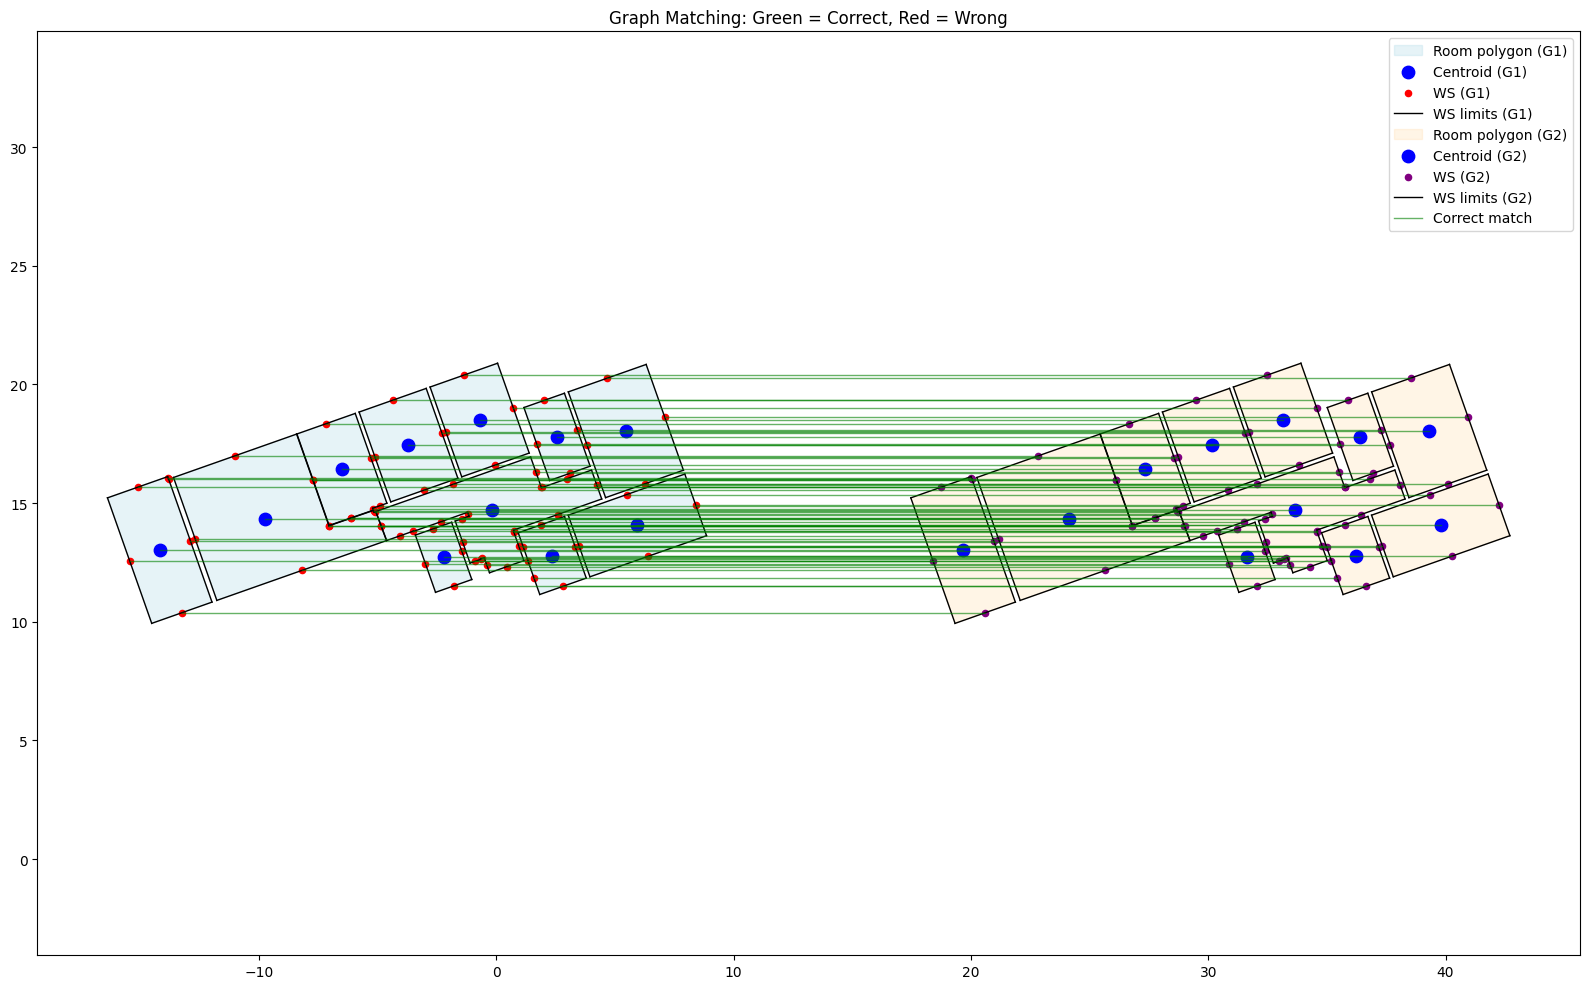

In [60]:
d1, d2, gt = train_list[0]
print(d1)
print(d2)
print(gt.shape)

# Visualize the two graphs
plot_two_graphs_with_matching(
    [d1, d2],
    gt_perm=gt,
    pred_perm=gt,
    original_graphs=original_graphs,
    viz_rooms=True,
    viz_ws=True,
    match_display="all",
)


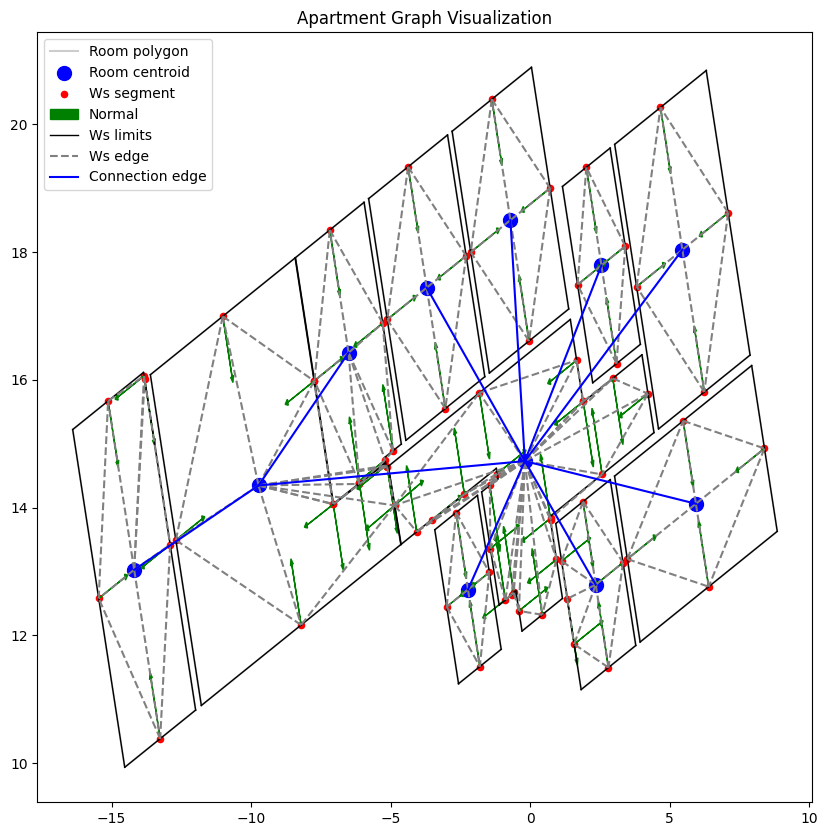

In [61]:
# plot d2 graph with plot_a_graph
g2 = pyg_data_to_nx_digraph(d2, original_graphs)
plot_a_graph([g2], viz_rooms=True, viz_ws=True, viz_openings=False, viz_room_connection=True, viz_normals=False, viz_room_normals=True, viz_walls=True)

In [62]:
train_dataset = GraphMatchingDataset(train_list)
val_dataset = GraphMatchingDataset(val_list)
test_dataset = GraphMatchingDataset(test_list)

In [63]:
# Percorsi per salvare i modelli
best_val_model_path = os.path.join(models_path, 'best_val_model.pt')
final_model_path = os.path.join(models_path, 'final_model.pt')

# Loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pyg_matching, generator=g)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)

# Modello e ottimizzatore
model = MatchingModel_GATv2Sinkhorn(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=out_dim).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Logger TensorBoard
writer = setup_tb_logger(
    base_dir="tb_logs",
    model_name=model._get_name(),
    dataset_name="GM_equal",
    experiment_name="exp1"
)

#model summary
print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

MatchingModel_GATv2Sinkhorn(
  (gnn): ModuleList(
    (0): GATv2Conv(7, 64, heads=1)
    (1): GATv2Conv(64, 32, heads=1)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (inst_norm): InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
)
Number of parameters: 5378


In [64]:
# visualize initial validation embeddings
batch = next(iter(val_loader))
h1_val, h2_val = batch[0], batch[1]
visualize_initial_embeddings(h1_val.x, h2_val.x, os.path.join(models_path, 'initial_room.png'), node_type_filter="room")
visualize_initial_embeddings(h1_val.x, h2_val.x, os.path.join(models_path, 'initial_ws.png'), node_type_filter="ws")
embedding_type = visualize_initial_embeddings(h1_val.x, h2_val.x, os.path.join(models_path, 'initial_all.png'), node_type_filter="all")

In [65]:
train_losses, val_losses, val_embeddings_history = train_loop(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    writer=writer,
    best_model_path=best_val_model_path,
    final_model_path=final_model_path,
    patience=patience,
    resume=False
)

Starting training...
[Epoch 0] Saved new best model.
Epoch 000 | Train Loss: 0.0564 | Val Loss: 0.0301 | Val Acc: 0.8844
[Epoch 1] Saved new best model.
Epoch 001 | Train Loss: 0.0442 | Val Loss: 0.0202 | Val Acc: 0.9143
[Epoch 2] Saved new best model.
Epoch 002 | Train Loss: 0.0404 | Val Loss: 0.0170 | Val Acc: 0.9159
[Epoch 3] Saved new best model.
Epoch 003 | Train Loss: 0.0382 | Val Loss: 0.0154 | Val Acc: 0.9211
[Epoch 4] Saved new best model.
Epoch 004 | Train Loss: 0.0377 | Val Loss: 0.0144 | Val Acc: 0.9219
[Epoch 5] Saved new best model.
Epoch 005 | Train Loss: 0.0358 | Val Loss: 0.0131 | Val Acc: 0.9231
Epoch 006 | Train Loss: 0.0355 | Val Loss: 0.0142 | Val Acc: 0.9223
[Epoch 7] Saved new best model.
Epoch 007 | Train Loss: 0.0348 | Val Loss: 0.0126 | Val Acc: 0.9198
[Epoch 8] Saved new best model.
Epoch 008 | Train Loss: 0.0350 | Val Loss: 0.0123 | Val Acc: 0.9259
Epoch 009 | Train Loss: 0.0349 | Val Loss: 0.0144 | Val Acc: 0.9214
[Epoch 10] Saved new best model.
Epoch 010 

In [66]:
create_embedding_gif_stride(val_embeddings_history, os.path.join(models_path, "embeddings_evolution.gif"), embedding_type=embedding_type, fps=0.001, node_type_filter="all")
create_embedding_gif_stride(val_embeddings_history, os.path.join(models_path, "embeddings_evolution_room.gif"), embedding_type=embedding_type, fps=0.001, node_type_filter="room")
create_embedding_gif_stride(val_embeddings_history, os.path.join(models_path, "embeddings_evolution_ws.gif"), embedding_type=embedding_type, fps=0.001, node_type_filter="ws")


MoviePy - Building file ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution.gif with imageio.


GIF saved at: ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution.gif
MoviePy - Building file ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution_room.gif with imageio.


GIF saved at: ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution_room.gif
MoviePy - Building file ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution_ws.gif with imageio.


GIF saved at: ../GNN_utilis/GNN/models\graph_matching\equal\embeddings_evolution_ws.gif


In [67]:
plot_losses(train_losses, val_losses, os.path.join(models_path, 'losses.png'))

In [68]:
checkpoint = torch.load(best_val_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

model.to(device)

# Evaluate on the test set
test_acc, test_loss, test_embeddings = evaluate_sinkhorn(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

inference_times = []
# use the model to predict the matching on a test graph
correct = 0
total_cols = 0

for i, (g1_out, g2_perm, gt_perm) in enumerate(test_list):
    start_time = time.time()
    result = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=True)
    end_time = time.time()
    inference_times.append(end_time - start_time)
    errors = (result != gt_perm.to(result.device)).sum().item()
    if errors > 0:
        print(f"Graph {i}: Errors found: {errors}")

    # Accuracy calculation after hungarian
    pred_idx = result.argmax(dim=0)
    target_idx = gt_perm.argmax(dim=0)
    correct += (pred_idx == target_idx).sum().item()
    total_cols += result.shape[1]

accuracy = correct / total_cols if total_cols > 0 else 0.0
print(f"Test Accuracy (after Hungarian): {accuracy:.4f}")

mean_inference_time = np.mean(inference_times)
std_inference_time = np.std(inference_times)
print(f"Inference time: {mean_inference_time:.6f} seconds (mean) ± {std_inference_time:.6f} seconds (std)")

Test Accuracy: 0.9285 | Test Loss: 0.0093
Graph 380: Errors found: 4
Graph 717: Errors found: 4
Test Accuracy (after Hungarian): 0.9999
Inference time: 0.009968 seconds (mean) ± 0.004007 seconds (std)


In [69]:
g1_out, g2_perm, gt_perm = test_list[236]
result = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=True)

plot_two_graphs_with_matching(
    [g1_out, g2_perm],
    gt_perm=gt_perm,
    pred_perm=result,
    original_graphs=original_graphs,
    viz_rooms=True,
    viz_ws=True,
    match_display="all",
    path=os.path.join(models_path, "test.png")
)


## Partial graphs (ws_room_dropout_noise_inc)


In [46]:
# Load preprocessed dataset (partial task)
gm_equal_preprocessed_path = os.path.join(GNN_PATH, "preprocessed", "graph_matching", "equal")  # solo per original_graphs (A-graph)
gm_partial_preprocessed_path = os.path.join(GNN_PATH, "preprocessed", "partial_graph_matching", "ws_room_dropout_noise_inc")
models_path = os.path.join(GNN_PATH, 'models', "partial_graph_matching", "ws_room_dropout_noise_inc")
os.makedirs(models_path, exist_ok=True)

original_graphs = deserialize_graph_matching_dataset(gm_equal_preprocessed_path, "original.pkl")
noise_graphs = deserialize_graph_matching_dataset(gm_partial_preprocessed_path, "noise.pkl")

train_list = deserialize_graph_matching_dataset(gm_partial_preprocessed_path, "train_dataset.pkl")
val_list   = deserialize_graph_matching_dataset(gm_partial_preprocessed_path, "valid_dataset.pkl")
test_list  = deserialize_graph_matching_dataset(gm_partial_preprocessed_path, "test_dataset.pkl")


Loaded 4895 pairs from ../GNN_utilis/GNN/preprocessed\graph_matching\equal\original.pkl
Loaded 24475 pairs from ../GNN_utilis/GNN/preprocessed\partial_graph_matching\ws_room_dropout_noise_inc\noise.pkl
Loaded 17132 pairs from ../GNN_utilis/GNN/preprocessed\partial_graph_matching\ws_room_dropout_noise_inc\train_dataset.pkl
Loaded 3671 pairs from ../GNN_utilis/GNN/preprocessed\partial_graph_matching\ws_room_dropout_noise_inc\valid_dataset.pkl
Loaded 3672 pairs from ../GNN_utilis/GNN/preprocessed\partial_graph_matching\ws_room_dropout_noise_inc\test_dataset.pkl


In [69]:
d1, d2, gt = train_list[0]
print(d1)
print(d2)
print("GT shape:", gt.shape)

train_dataset = GraphMatchingDataset(train_list)
val_dataset   = GraphMatchingDataset(val_list)
test_dataset  = GraphMatchingDataset(test_list)


Data(x=[89, 7], edge_index=[2, 166], name='3610', node_names=[89], permutation=[89])
Data(x=[23, 7], edge_index=[2, 22], name='3610', node_names=[23], permutation=[23])
GT shape: torch.Size([89, 23])


In [104]:
# Percorsi per salvare i modelli
experiment_name = "EXP10_heads4_cosine_wbce_maxiter30_noscheduler"

exp_models_path = os.path.join(models_path, experiment_name)
os.makedirs(exp_models_path, exist_ok=True)

best_val_model_path = os.path.join(exp_models_path, 'best_val_model.pt')
final_model_path = os.path.join(exp_models_path, 'final_model.pt')

# Loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pyg_matching, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_pyg_matching)


#### EXP10_heads4_cosine_wbce_maxiter30_noscheduler

**Modello**: `MatchingModel_MLPGATv2Sinkhorn` — MLP di omogeneizzazione feature + GATv2 multi-head + affinity + Sinkhorn con `dummy_row` per il matching rettangolare (N_A ≠ N_S).

**Iperparametri di base**: `hidden_dim=64`, `out_dim=32`, `num_epochs=200`, `learning_rate=1e-3`, `batch_size=16`, `weight_decay=5e-5`, `patience=200` (early stopping de facto disattivato).


In [ ]:
model = MatchingModel_MLPGATv2Sinkhorn(
    in_dim=in_dim,
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    sinkhorn_max_iter=30,
    sinkhorn_tau=1.0,
    heads=4,
    num_layers=2,
    use_cosine=True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

writer = setup_tb_logger(
    base_dir="tb_logs",
    model_name=model._get_name(),
    dataset_name="PGM_ws_room_dropout_noise_inc",
    experiment_name=experiment_name
)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


MatchingModel_MLPGATv2Sinkhorn(
  (mlp): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (gnn): ModuleList(
    (0): GATv2Conv(64, 64, heads=4)
    (1): GATv2Conv(64, 32, heads=4)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (inst_norm): InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
)
Number of parameters: 55074


In [106]:
# Sanity check: conferma che use_cosine sposta davvero la norma degli embedding
model.eval()
with torch.no_grad():
    g1_test, g2_test, _ = train_dataset[0]
    h1 = model.encode(model.mlp(g1_test.x.to(device)), g1_test.edge_index.to(device))
    h2 = model.encode(model.mlp(g2_test.x.to(device)), g2_test.edge_index.to(device))
    print("Norma media embedding A-graph (grezza):", h1.norm(dim=-1).mean().item())
    print("Norma media embedding S-graph (grezza):", h2.norm(dim=-1).mean().item())
    if model.use_cosine:
        h1n, h2n = F.normalize(h1, p=2, dim=-1), F.normalize(h2, p=2, dim=-1)
        print("Norma media dopo normalize (deve essere ~1.0):", h1n.norm(dim=-1).mean().item(), h2n.norm(dim=-1).mean().item())
model.train()

Norma media embedding A-graph (grezza): 0.25570613145828247
Norma media embedding S-graph (grezza): 0.2646508514881134
Norma media dopo normalize (deve essere ~1.0): 1.0 1.0


MatchingModel_MLPGATv2Sinkhorn(
  (mlp): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (gnn): ModuleList(
    (0): GATv2Conv(64, 64, heads=4)
    (1): GATv2Conv(64, 32, heads=4)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (inst_norm): InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
)

In [107]:
import inspect
print(inspect.getsource(bce_permutation_loss))
print(f"\nexperiment_name attivo: {experiment_name}")
print(f"sinkhorn_max_iter attivo: {model.sinkhorn_max_iter}")
print(f"sinkhorn_tau attivo: {model.sinkhorn_tau}")
print(f"use_cosine attivo: {model.use_cosine}")
print(f"Architettura modello:\n{model}")   

def bce_permutation_loss(P, P_gt, eps: float = 1e-9):
    """
    Element-wise BCE, pesata sulla classe positiva. pos_weight = N1 - 1,
    ricalcolato per ogni grafo -- versione lineare, quella della base
    EXP06_heads4_cosine_wbce_maxiter30 (la migliore finora).
    """
    N1 = P_gt.shape[0]
    pos_weight = max(N1 - 1, 1)
    return - (pos_weight * P_gt * torch.log(P + eps) + (1 - P_gt) * torch.log(1 - P + eps)).mean()


experiment_name attivo: EXP10_heads4_cosine_wbce_maxiter30_noscheduler
sinkhorn_max_iter attivo: 30
sinkhorn_tau attivo: 1.0
use_cosine attivo: True
Architettura modello:
MatchingModel_MLPGATv2Sinkhorn(
  (mlp): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (gnn): ModuleList(
    (0): GATv2Conv(64, 64, heads=4)
    (1): GATv2Conv(64, 32, heads=4)
  )
  (dropout): Dro

In [108]:
train_losses, val_losses, val_embeddings_history = train_loop(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=num_epochs,
    writer=writer,
    best_model_path=best_val_model_path,
    final_model_path=final_model_path,
    patience=patience,
    resume=False
    #scheduler=scheduler
)


Starting training...
[Epoch 0] Saved new best model.
Epoch 000 | Train Loss: 2.8120 | Val Loss: 2.1005 | Val Acc: 0.4110
[Epoch 1] Saved new best model.
Epoch 001 | Train Loss: 2.1752 | Val Loss: 1.7484 | Val Acc: 0.4720
[Epoch 2] Saved new best model.
Epoch 002 | Train Loss: 1.9539 | Val Loss: 1.6115 | Val Acc: 0.4905
[Epoch 3] Saved new best model.
Epoch 003 | Train Loss: 1.8489 | Val Loss: 1.5368 | Val Acc: 0.5088
[Epoch 4] Saved new best model.
Epoch 004 | Train Loss: 1.7875 | Val Loss: 1.5056 | Val Acc: 0.4985
[Epoch 5] Saved new best model.
Epoch 005 | Train Loss: 1.7394 | Val Loss: 1.4291 | Val Acc: 0.5211
[Epoch 6] Saved new best model.
Epoch 006 | Train Loss: 1.7047 | Val Loss: 1.4221 | Val Acc: 0.5255
[Epoch 7] Saved new best model.
Epoch 007 | Train Loss: 1.6870 | Val Loss: 1.3976 | Val Acc: 0.5286
[Epoch 8] Saved new best model.
Epoch 008 | Train Loss: 1.6562 | Val Loss: 1.3819 | Val Acc: 0.5285
[Epoch 9] Saved new best model.
Epoch 009 | Train Loss: 1.6420 | Val Loss: 1.36

In [109]:
plot_losses(train_losses, val_losses, os.path.join(exp_models_path, 'losses.png'))


### Metriche corrette (F1, precision, recall, accuracy TP+TN su N x M)



In [ ]:
def compute_confusion_metrics(pred_binary: torch.Tensor, gt_binary: torch.Tensor):
    pred = pred_binary.bool()
    gt = gt_binary.bool()

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()
    tn = (~pred & ~gt).sum().item()

    return tp, fp, fn, tn


def evaluate_test_metrics(model, test_list, use_hungarian=True):
    total_tp = total_fp = total_fn = total_tn = 0
    inference_times = []
    per_graph_errors = []

    for i, (g1_out, g2_perm, gt_perm) in enumerate(test_list):
        start_time = time.time()
        result = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=use_hungarian)
        end_time = time.time()
        inference_times.append(end_time - start_time)

        gt = gt_perm.to(result.device)
        tp, fp, fn, tn = compute_confusion_metrics(result, gt)
        total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn

        errors = fp + fn
        if errors > 0:
            per_graph_errors.append((i, errors))

    total_cells = total_tp + total_fp + total_fn + total_tn
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy  = (total_tp + total_tn) / total_cells if total_cells > 0 else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "tp": total_tp, "fp": total_fp, "fn": total_fn, "tn": total_tn,
        "mean_inference_time": float(np.mean(inference_times)),
        "std_inference_time": float(np.std(inference_times)),
        "per_graph_errors": per_graph_errors,
    }

def binarize_by_column_argmax(S: torch.Tensor) -> torch.Tensor:
    hard = torch.zeros_like(S)
    row_idx = S.argmax(dim=0)
    col_idx = torch.arange(S.shape[1], device=S.device)
    hard[row_idx, col_idx] = 1.0
    return hard


def evaluate_sinkhorn_extended(model, loader, eps: float = 1e-9):
    model.eval()
    correct = 0
    total_cols = 0
    total_loss = 0.0
    num_graphs = 0
    all_embeddings = []
    total_tp = total_fp = total_fn = total_tn = 0

    device = next(model.parameters()).device
    with torch.no_grad():
        for batch1, batch2, perm_list in loader:
            batch1 = batch1.to(device)
            batch2 = batch2.to(device)
            perm_list = [p.to(device) for p in perm_list]

            batch_idx1 = batch1.batch
            batch_idx2 = batch2.batch
            pred_perm_list, batch_embeddings = model(batch1, batch2, perm_list, batch_idx1, batch_idx2)

            for P, P_gt in zip(pred_perm_list, perm_list):
                pred_idx = P.argmax(dim=0)
                target_idx = P_gt.argmax(dim=0)
                correct += (pred_idx == target_idx).sum().item()
                total_cols += P.shape[1]

                loss = bce_permutation_loss(P, P_gt, eps)
                total_loss += loss.item()
                num_graphs += 1

                P_hard = binarize_by_column_argmax(P)
                tp, fp, fn, tn = compute_confusion_metrics(P_hard, P_gt)
                total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn

            all_embeddings.extend(batch_embeddings)

    avg_acc = correct / total_cols if total_cols > 0 else 0.0
    avg_loss = total_loss / num_graphs if num_graphs > 0 else 0.0

    total_cells = total_tp + total_fp + total_fn + total_tn
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy  = (total_tp + total_tn) / total_cells if total_cells > 0 else 0.0

    sinkhorn_metrics = {
        "precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy,
        "tp": total_tp, "fp": total_fp, "fn": total_fn, "tn": total_tn,
    }
    return avg_acc, avg_loss, all_embeddings, sinkhorn_metrics


### Valutazione finale sul test set


### Metriche estese per-tipo-nodo / per-grafo


In [ ]:
def get_soft_matrix(model, data1, data2, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        data1 = data1.to(device)
        data2 = data2.to(device)
        batch_idx1 = torch.zeros(data1.num_nodes, dtype=torch.long, device=device)
        batch_idx2 = torch.zeros(data2.num_nodes, dtype=torch.long, device=device)
        soft_list, _ = model(data1, data2, perm_list=None, batch_idx1=batch_idx1, batch_idx2=batch_idx2, inference=False)
        return soft_list[0]



def compute_extended_metrics(model, data_list, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    # accumulatori GLOBALI per l'accuracy corretta (TP+TN)/(N*M), su tutte le celle di tutti i grafi
    sink_tp = sink_fp = sink_fn = sink_tn = 0
    hung_tp = hung_fp = hung_fn = hung_tn = 0

    # accumulatori per TIPO NODO (room / ws): stessa logica, ristretta alle colonne del tipo
    sink_room_tp = sink_room_fp = sink_room_fn = sink_room_tn = 0
    sink_ws_tp   = sink_ws_fp   = sink_ws_fn   = sink_ws_tn   = 0
    hung_room_tp = hung_room_fp = hung_room_fn = hung_room_tn = 0
    hung_ws_tp   = hung_ws_fp   = hung_ws_fn   = hung_ws_tn   = 0

    sink_per_graph_acc = []
    hung_per_graph_acc = []
    sink_per_graph_f1  = []
    hung_per_graph_f1  = []
    sink_errors         = []
    hung_errors         = []
    confidence_list      = []

    def acc(tp, fp, fn, tn):
        total = tp + fp + fn + tn
        return (tp + tn) / total if total > 0 else 0.0

    def f1(tp, fp, fn):
        denom = 2 * tp + fp + fn
        return (2 * tp) / denom if denom > 0 else 0.0

    with torch.no_grad():
        for g1, g2, gt in data_list:
            gt_dev     = gt.to(device)
            target_idx = gt_dev.argmax(dim=0)

            node_types = g2.x[:, :2]
            room_mask  = (node_types[:, 0] > 0).to(device)
            ws_mask    = (node_types[:, 1] > 0).to(device)
            n          = g2.num_nodes

            # -- SINKHORN (soft_S vero, pre-hardening topk) --
            soft       = get_soft_matrix(model, g1, g2, device=device)
            confidence_list.append(soft.max(dim=0).values.mean().item())
            sink_hard  = binarize_by_column_argmax(soft)

            sink_pred  = soft.argmax(dim=0)
            sink_n_ok  = (sink_pred == target_idx).sum().item()
            sink_errors.append(n - sink_n_ok)

            tp, fp, fn, tn = compute_confusion_metrics(sink_hard, gt_dev)
            sink_tp += tp; sink_fp += fp; sink_fn += fn; sink_tn += tn
            sink_per_graph_acc.append(acc(tp, fp, fn, tn))
            sink_per_graph_f1.append(f1(tp, fp, fn))

            tp_r, fp_r, fn_r, tn_r = compute_confusion_metrics(sink_hard[:, room_mask], gt_dev[:, room_mask])
            sink_room_tp += tp_r; sink_room_fp += fp_r; sink_room_fn += fn_r; sink_room_tn += tn_r

            tp_w, fp_w, fn_w, tn_w = compute_confusion_metrics(sink_hard[:, ws_mask], gt_dev[:, ws_mask])
            sink_ws_tp += tp_w; sink_ws_fp += fp_w; sink_ws_fn += fn_w; sink_ws_tn += tn_w

            # -- HUNGARIAN --
            hard       = predict_matching_matrix(model, g1, g2, use_hungarian=True)
            hung_pred  = hard.argmax(dim=0)
            hung_n_ok  = (hung_pred == target_idx).sum().item()
            hung_errors.append(n - hung_n_ok)

            tp, fp, fn, tn = compute_confusion_metrics(hard, gt_dev)
            hung_tp += tp; hung_fp += fp; hung_fn += fn; hung_tn += tn
            hung_per_graph_acc.append(acc(tp, fp, fn, tn))
            hung_per_graph_f1.append(f1(tp, fp, fn))

            tp_r, fp_r, fn_r, tn_r = compute_confusion_metrics(hard[:, room_mask], gt_dev[:, room_mask])
            hung_room_tp += tp_r; hung_room_fp += fp_r; hung_room_fn += fn_r; hung_room_tn += tn_r

            tp_w, fp_w, fn_w, tn_w = compute_confusion_metrics(hard[:, ws_mask], gt_dev[:, ws_mask])
            hung_ws_tp += tp_w; hung_ws_fp += fp_w; hung_ws_fn += fn_w; hung_ws_tn += tn_w

    ng = len(data_list)

    return {
        # Sinkhorn - accuracy corretta (TP+TN)/(N*M)
        "sink_acc_global":    acc(sink_tp, sink_fp, sink_fn, sink_tn),
        "sink_acc_per_graph": sum(sink_per_graph_acc) / ng,
        "sink_acc_room":      acc(sink_room_tp, sink_room_fp, sink_room_fn, sink_room_tn),
        "sink_acc_ws":        acc(sink_ws_tp, sink_ws_fp, sink_ws_fn, sink_ws_tn),
        "sink_f1_global":     f1(sink_tp, sink_fp, sink_fn),
        "sink_f1_per_graph":  sum(sink_per_graph_f1) / ng,
        "sink_f1_room":       f1(sink_room_tp, sink_room_fp, sink_room_fn),
        "sink_f1_ws":         f1(sink_ws_tp, sink_ws_fp, sink_ws_fn),
        "sink_perfect_pct":   sum(1 for e in sink_errors if e == 0) / ng,
        "sink_n_perfect":     sum(1 for e in sink_errors if e == 0),
        "sink_mean_errors":   sum(sink_errors) / ng,
        "sink_max_errors":    max(sink_errors),
        # Hungarian
        "hung_acc_global":    acc(hung_tp, hung_fp, hung_fn, hung_tn),
        "hung_acc_per_graph": sum(hung_per_graph_acc) / ng,
        "hung_acc_room":      acc(hung_room_tp, hung_room_fp, hung_room_fn, hung_room_tn),
        "hung_acc_ws":        acc(hung_ws_tp, hung_ws_fp, hung_ws_fn, hung_ws_tn),
        "hung_f1_global":     f1(hung_tp, hung_fp, hung_fn),
        "hung_f1_per_graph":  sum(hung_per_graph_f1) / ng,
        "hung_f1_room":       f1(hung_room_tp, hung_room_fp, hung_room_fn),
        "hung_f1_ws":         f1(hung_ws_tp, hung_ws_fp, hung_ws_fn),
        "hung_perfect_pct":   sum(1 for e in hung_errors if e == 0) / ng,
        "hung_n_perfect":     sum(1 for e in hung_errors if e == 0),
        "hung_mean_errors":   sum(hung_errors) / ng,
        "hung_max_errors":    max(hung_errors),
        # Confidence
        "sinkhorn_conf":      sum(confidence_list) / ng,
        "n_graphs":           ng,
    }


In [ ]:
checkpoint = torch.load(best_val_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
model.to(device)

# --- Valutazione SINKHORN (soft, pre-Hungarian, binarizzata per colonna) ---
test_acc_sinkhorn, test_loss, test_embeddings, sinkhorn_metrics = evaluate_sinkhorn_extended(model, test_loader)
print("=== SINKHORN (pre-Hungarian) ===")
print(f"Accuracy (colonne, monitoraggio): {test_acc_sinkhorn:.6f} | Test Loss: {test_loss:.6f}")
print(f"F1:        {sinkhorn_metrics['f1']:.4f}")
print(f"Accuracy (TP+TN)/(N*M): {sinkhorn_metrics['accuracy']:.4f}")
print(f"TP={sinkhorn_metrics['tp']} FP={sinkhorn_metrics['fp']} FN={sinkhorn_metrics['fn']} TN={sinkhorn_metrics['tn']}")

# --- Valutazione HUNGARIAN (hard, post-discretizzazione) ---
metrics = evaluate_test_metrics(model, test_list, use_hungarian=True)
print("\n=== HUNGARIAN (post-discretizzazione) ===")
print(f"F1:        {metrics['f1']:.4f}")
print(f"Accuracy (TP+TN)/(N*M): {metrics['accuracy']:.4f}")
print(f"TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']} TN={metrics['tn']}")
print(f"Inference time: {metrics['mean_inference_time']:.6f}s (mean) +/- {metrics['std_inference_time']:.6f}s (std)")

import time

for g1_out, g2_perm, gt_perm in test_list[:3]:
    _ = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=False)

sinkhorn_times = []
for g1_out, g2_perm, gt_perm in test_list:
    start_time = time.perf_counter()      # piu' preciso di time.time() per benchmark
    _ = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=False)
    sinkhorn_times.append(time.perf_counter() - start_time)

print(f"Inference time (Sinkhorn, no Hungarian): {np.mean(sinkhorn_times):.6f}s (mean) +/- {np.std(sinkhorn_times):.6f}s (std)")

for graph_idx, n_errors in metrics["per_graph_errors"][:20]:
    print(f"Graph {graph_idx}: Errors found: {n_errors}")

# --- Metriche estese per-tipo-nodo / per-grafo (identiche a quelle sull'equal) ---
print("\nCalcolo metriche estese (richiede ~2 volte il tempo di inferenza)...")
m = compute_extended_metrics(model, test_list)

print()
print("=" * 62)
print(f"  {experiment_name} — METRICHE ESTESE — TEST SET (partial)")
print("=" * 62)
print(f"  {'Metrica':<30} {'Sinkhorn':>10} {'Hungarian':>10}")
print(f"  {'-'*50}")
print(f"  {'acc_global':<30} {m['sink_acc_global']:>10.4f} {m['hung_acc_global']:>10.4f}")
print(f"  {'f1_global':<30} {m['sink_f1_global']:>10.4f} {m['hung_f1_global']:>10.4f}")
print(f"  {'f1_per_graph':<30} {m['sink_f1_per_graph']:>10.4f} {m['hung_f1_per_graph']:>10.4f}")
print(f"  {'f1_room':<30} {m['sink_f1_room']:>10.4f} {m['hung_f1_room']:>10.4f}")
print(f"  {'f1_ws':<30} {m['sink_f1_ws']:>10.4f} {m['hung_f1_ws']:>10.4f}")
print(f"  {'perfect_pct':<30} {m['sink_perfect_pct']*100:>9.2f}% {m['hung_perfect_pct']*100:>9.2f}%")
print(f"  {'n_perfect_graphs':<30} {m['sink_n_perfect']:>10} {m['hung_n_perfect']:>10}")
print(f"  {'mean_errors_per_graph':<30} {m['sink_mean_errors']:>10.4f} {m['hung_mean_errors']:>10.4f}")
print(f"  {'max_errors_in_a_graph':<30} {m['sink_max_errors']:>10} {m['hung_max_errors']:>10}")
print(f"  {'-'*50}")
print(f"  {'sinkhorn_confidence':<30} {m['sinkhorn_conf']:>10.4f}")
print("=" * 62)

# Salvataggio automatico dei risultati per tracciabilita' (history.json)
history = {
    "experiment_name": experiment_name,
    "task": "partial_graph_matching/ws_room_dropout_noise_inc",
    "train_losses": train_losses,
    "val_losses": val_losses,
    "test_loss": test_loss,
    "sinkhorn": {
        "acc_colonne": test_acc_sinkhorn,
        "precision": sinkhorn_metrics["precision"],
        "recall": sinkhorn_metrics["recall"],
        "f1": sinkhorn_metrics["f1"],
        "accuracy": sinkhorn_metrics["accuracy"],
        "confusion": {"tp": sinkhorn_metrics["tp"], "fp": sinkhorn_metrics["fp"], "fn": sinkhorn_metrics["fn"], "tn": sinkhorn_metrics["tn"]},
        "mean_inference_time": float(np.mean(sinkhorn_times)),   
        "std_inference_time": float(np.std(sinkhorn_times)),     
    },
    "hungarian": {
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "accuracy": metrics["accuracy"],
        "confusion": {"tp": metrics["tp"], "fp": metrics["fp"], "fn": metrics["fn"], "tn": metrics["tn"]},
        "mean_inference_time": metrics["mean_inference_time"],
        "std_inference_time": metrics["std_inference_time"],
    },
    "extended": m,
}
with open(os.path.join(exp_models_path, "history.json"), "w") as f:
    json.dump(history, f, indent=2)
print(f"\nHistory salvata in {os.path.join(exp_models_path, 'history.json')}")


=== SINKHORN (pre-Hungarian) ===
Accuracy (colonne, monitoraggio): 0.583619 | Test Loss: 1.156871
F1:        0.5836
Accuracy (TP+TN)/(N*M): 0.9906
TP=44529 FP=31769 FN=31769 TN=6640214

=== HUNGARIAN (post-discretizzazione) ===
F1:        0.5936
Accuracy (TP+TN)/(N*M): 0.9908
TP=45292 FP=31006 FN=31006 TN=6640977
Inference time: 0.012790s (mean) +/- 0.003141s (std)
Inference time (Sinkhorn, no Hungarian): 0.013892s (mean) +/- 0.003860s (std)
Graph 0: Errors found: 14
Graph 1: Errors found: 78
Graph 2: Errors found: 16
Graph 3: Errors found: 4
Graph 4: Errors found: 6
Graph 5: Errors found: 10
Graph 6: Errors found: 16
Graph 7: Errors found: 20
Graph 8: Errors found: 8
Graph 9: Errors found: 24
Graph 10: Errors found: 12
Graph 11: Errors found: 28
Graph 12: Errors found: 42
Graph 13: Errors found: 6
Graph 14: Errors found: 34
Graph 15: Errors found: 16
Graph 16: Errors found: 20
Graph 17: Errors found: 4
Graph 18: Errors found: 26
Graph 19: Errors found: 4

Calcolo metriche estese (rich

In [75]:
# Sanity check visivo su un grafo del test set
idx = 0
g1_out, g2_perm, gt_perm = test_list[idx]
result = predict_matching_matrix(model, g1_out, g2_perm, use_hungarian=True)

plot_two_graphs_with_matching(
    [g1_out, g2_perm],
    gt_perm=gt_perm,
    pred_perm=result,
    original_graphs=original_graphs,
    noise_graphs=noise_graphs,
    viz_rooms=True,
    viz_ws=True,
    match_display="all",
    path=os.path.join(models_path, "test.png")
)


# Analisi aggiuntive per esperimento


## Scheduler — EXP01_batch16_scheduler


In [31]:
import json, os

exp01_scheduler_path = os.path.join(models_path, "EXP01_batch16_scheduler", "history.json")
with open(exp01_scheduler_path) as f:
    history = json.load(f)

val_losses = history["val_losses"]

lr = 1e-3
factor, patience = 0.5, 15
best = float("inf")
bad_epochs = 0
lr_history = []

for epoch, vl in enumerate(val_losses):
    lr_history.append(lr)
    if vl < best:
        best = vl
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs > patience:
            lr = lr * factor
            bad_epochs = 0
            print(f"Epoch {epoch}: LR ridotto a {lr:.2e}")

print("LR finale:", lr)


Epoch 180: LR ridotto a 5.00e-04
LR finale: 0.0005


In [29]:
import numpy as np

val_losses = history["val_losses"]
best_epoch = int(np.argmin(val_losses))
best_before_180 = min(val_losses[:180])
best_after_180 = min(val_losses[180:]) if len(val_losses) > 180 else None

print("Epoca del best checkpoint:", best_epoch)
print("Miglior val_loss prima dell'epoca 180:", best_before_180)
print("Miglior val_loss da epoca 180 in poi:", best_after_180)

Epoca del best checkpoint: 186
Miglior val_loss prima dell'epoca 180: 0.01563841443172973
Miglior val_loss da epoca 180 in poi: 0.015600413614077272


## Ablation heads — EXP02_heads2 / EXP02_heads3 / EXP02_heads4

Sweep eseguito su EXP02_heads2/3/4 (confrontati con la baseline heads=1), prima dell'aggiunta di weighted BCE e max_iter=30. I valori assoluti di F1 non sono confrontabili con la configurazione finale EXP06.


In [50]:
import matplotlib.pyplot as plt
import numpy as np

heads = [1, 2, 3, 4]

# Sinkhorn (pre-Hungarian)
sink_f1_global = [0.7334, 0.6994, 0.7156, 0.7516]
sink_f1_room   = [0.1244, 0.1318, 0.1349, 0.1311]
sink_f1_ws     = [0.8718, 0.8283, 0.8475, 0.8925]
sink_test_loss = [0.020578, 0.019114, 0.017773, 0.015791]
sink_confidence= [0.4984, 0.5596, 0.5810, 0.6151]

# Hungarian (post-discretizzazione)
hung_f1_global   = [0.7565, 0.7169, 0.7378, 0.7572]
hung_f1_room     = [0.1854, 0.1728, 0.2146, 0.1408]
hung_f1_ws       = [0.8863, 0.8405, 0.8567, 0.8972]
hung_mean_errors = [5.0594, 5.8832, 5.4480, 5.0447]
hung_perfect_pct = [3.92, 5.56, 6.45, 6.48]

COLORS = {"global": "#2f6fed", "room": "#d64545", "ws": "#1f9d55"}

**F1 per tipo di nodo al variare degli attention heads (Hungarian)** — confronta F1 globale, room e wall-surface al variare del numero di heads.


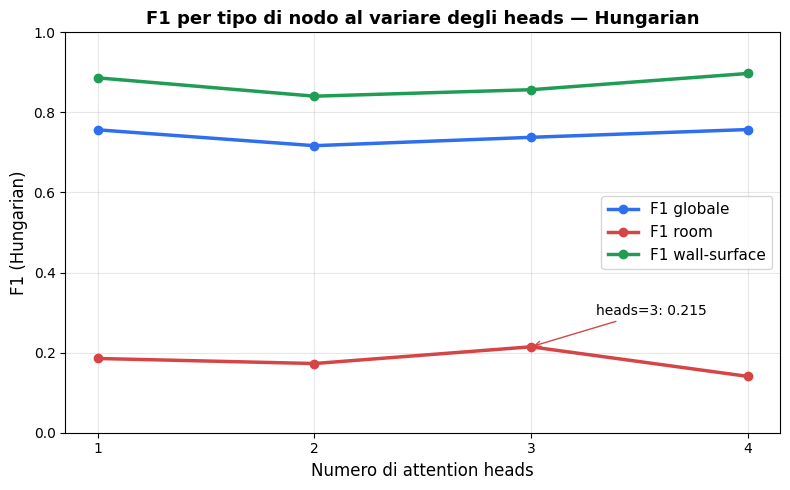

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(heads, hung_f1_global, marker='o', linewidth=2.5, label='F1 globale', color=COLORS["global"])
ax.plot(heads, hung_f1_room, marker='o', linewidth=2.5, label='F1 room', color=COLORS["room"])
ax.plot(heads, hung_f1_ws, marker='o', linewidth=2.5, label='F1 wall-surface', color=COLORS["ws"])

ax.set_xlabel("Numero di attention heads", fontsize=12)
ax.set_ylabel("F1 (Hungarian)", fontsize=12)
ax.set_title("F1 per tipo di nodo al variare degli heads — Hungarian", fontsize=13, fontweight='bold')
ax.set_xticks(heads)
ax.legend(fontsize=11, loc='center right')
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# annotazione sul punto più alto di F1 room
best_room_idx = int(np.argmax(hung_f1_room))
ax.annotate(f'heads={heads[best_room_idx]}: {hung_f1_room[best_room_idx]:.3f}',
            xy=(heads[best_room_idx], hung_f1_room[best_room_idx]),
            xytext=(heads[best_room_idx]+0.3, hung_f1_room[best_room_idx]+0.08),
            arrowprops=dict(arrowstyle='->', color=COLORS["room"]))

plt.tight_layout()
plt.savefig("heads_f1_per_tipo_hungarian.png", dpi=150)
plt.show()

**F1 room: Sinkhorn (soft) vs Hungarian (hard), per numero di heads** — quanto la discretizzazione finale cambia l'F1 sui nodi room rispetto all'output soft.


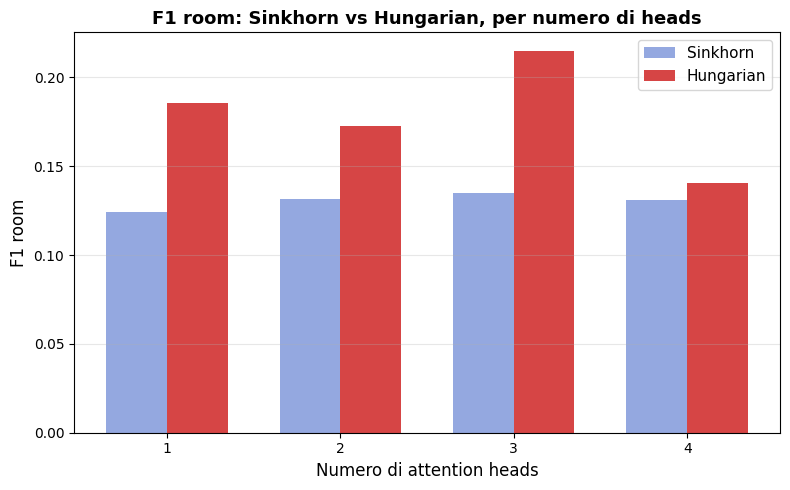

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(heads))
width = 0.35

ax.bar(x - width/2, sink_f1_room, width, label='Sinkhorn', color='#94a8e0')
ax.bar(x + width/2, hung_f1_room, width, label='Hungarian', color=COLORS["room"])

ax.set_xlabel("Numero di attention heads", fontsize=12)
ax.set_ylabel("F1 room", fontsize=12)
ax.set_title("F1 room: Sinkhorn vs Hungarian, per numero di heads", fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(heads)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("heads_f1_room_sink_vs_hung.png", dpi=150)
plt.show()

**Test loss vs F1 globale al variare degli heads** — la loss scende in modo monotono con gli heads, l'F1 no (es. heads=2): le due metriche divergono.


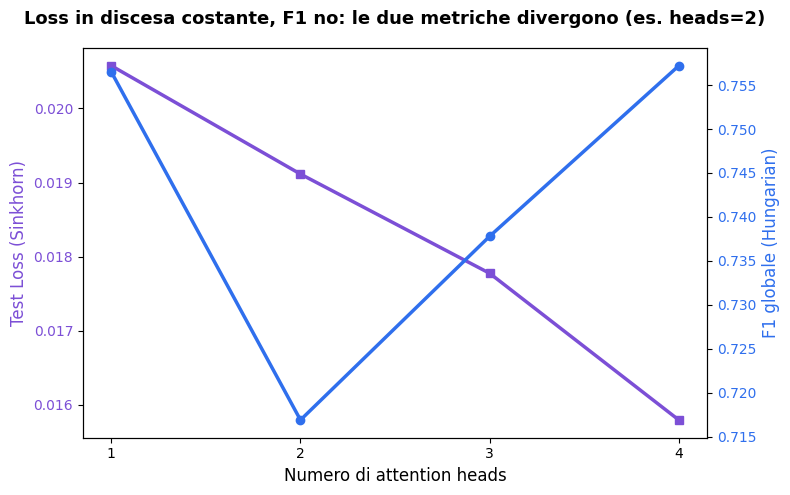

In [53]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = '#7c4fd6'
ax1.set_xlabel("Numero di attention heads", fontsize=12)
ax1.set_ylabel("Test Loss (Sinkhorn)", color=color1, fontsize=12)
ax1.plot(heads, sink_test_loss, marker='s', linewidth=2.5, color=color1, label='Test Loss')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(heads)

ax2 = ax1.twinx()
color2 = COLORS["global"]
ax2.set_ylabel("F1 globale (Hungarian)", color=color2, fontsize=12)
ax2.plot(heads, hung_f1_global, marker='o', linewidth=2.5, color=color2, label='F1 globale')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle("Loss in discesa costante, F1 no: le due metriche divergono (es. heads=2)",
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig("loss_vs_f1_divergenza.png", dpi=150)
plt.show()

**Grafi matchati perfettamente ed errore medio per grafo, al variare degli heads** — percentuale di grafi con matching perfetto (cresce con gli heads) ed errore medio per grafo (andamento non monotono).


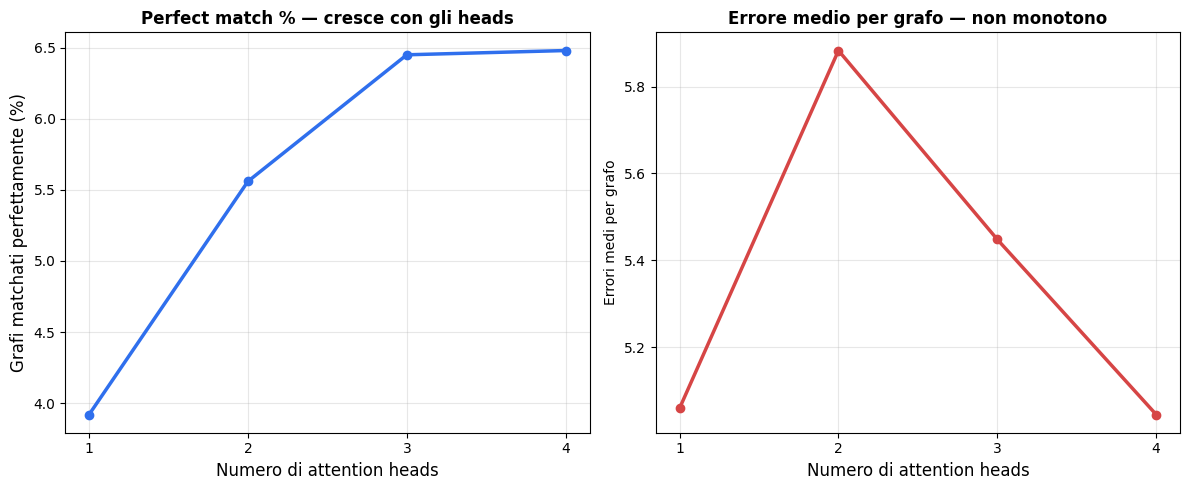

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(heads, hung_perfect_pct, marker='o', linewidth=2.5, color=COLORS["global"])
axes[0].set_xlabel("Numero di attention heads", fontsize=12)
axes[0].set_ylabel("Grafi matchati perfettamente (%)", fontsize=12)
axes[0].set_title("Perfect match % — cresce con gli heads", fontsize=12, fontweight='bold')
axes[0].set_xticks(heads)
axes[0].grid(alpha=0.3)

axes[1].plot(heads, hung_mean_errors, marker='o', linewidth=2.5, color=COLORS["room"])
axes[1].set_xlabel("Numero di attention heads", fontsize=12)
axes[1].set_ylabel("Errori medi per grafo")
axes[1].set_title("Errore medio per grafo — non monotono", fontsize=12, fontweight='bold')
axes[1].set_xticks(heads)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("perfect_pct_mean_errors.png", dpi=150)
plt.show()

## Weighted BCE — statistiche sulla dimensione dei grafi (N1)


In [24]:
import numpy as np

N1_values = [g1.num_nodes for g1, g2, gt in train_list]  # o test_list
N1_values = np.array(N1_values)

print("Min:", N1_values.min())
print("Mediana:", np.median(N1_values))
print("Media:", N1_values.mean())
print("Max:", N1_values.max())
print("Percentile 90:", np.percentile(N1_values, 90))
print("Percentile 99:", np.percentile(N1_values, 99))

Min: 5
Mediana: 76.0
Media: 78.55936259631099
Max: 310
Percentile 90: 116.0
Percentile 99: 178.0


## Convergenza Sinkhorn — EXP03_heads4_cosine


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def run_convergence_check_v3(model, checkpoint_path, sample_graphs, max_iter_values, device=None):
    if device is None:
        device = next(model.parameters()).device
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.eval()
    original_max_iter = model.sinkhorn_max_iter
    results = {}
    with torch.no_grad():
        for mi in max_iter_values:
            model.sinkhorn_max_iter = mi
            results[mi] = [get_soft_matrix(model, g1, g2, device=device).cpu() for g1, g2, gt in sample_graphs]
    model.sinkhorn_max_iter = original_max_iter
    deltas = {}
    for i in range(1, len(max_iter_values)):
        mi_prev, mi_curr = max_iter_values[i-1], max_iter_values[i]
        deltas[mi_curr] = np.mean([(results[mi_curr][j] - results[mi_prev][j]).abs().mean().item() for j in range(len(sample_graphs))])
    first_delta = deltas[max_iter_values[1]]
    deltas_pct = {mi: (d / first_delta * 100) for mi, d in deltas.items()}
    return {"deltas": deltas, "deltas_pct": deltas_pct, "max_iter_values": max_iter_values}


def check_disagreement_by_type_full(model, checkpoint_path, sample_graphs, max_iter_values, reference_mi=100, device=None):
    """
    Metrica decisiva: per ogni max_iter, % di colonne (separate per room/ws) la cui
    decisione finale (argmax) e' diversa rispetto a un riferimento a molte iterazioni.
    """
    if device is None:
        device = next(model.parameters()).device
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
    model.eval()
    original_max_iter = model.sinkhorn_max_iter

    model.sinkhorn_max_iter = reference_mi
    refs = []
    with torch.no_grad():
        for g1, g2, gt in sample_graphs:
            refs.append(get_soft_matrix(model, g1, g2, device=device).argmax(dim=0))

    results = {}
    with torch.no_grad():
        for mi in max_iter_values:
            model.sinkhorn_max_iter = mi
            room_diff, room_total, ws_diff, ws_total = 0, 0, 0, 0
            for (g1, g2, gt), pred_ref in zip(sample_graphs, refs):
                node_types = g2.x[:, :2]
                room_mask = (node_types[:, 0] > 0).to(device)
                ws_mask = (node_types[:, 1] > 0).to(device)
                pred_mi = get_soft_matrix(model, g1, g2, device=device).argmax(dim=0)
                diff = (pred_mi != pred_ref)
                room_diff += diff[room_mask].sum().item(); room_total += room_mask.sum().item()
                ws_diff += diff[ws_mask].sum().item(); ws_total += ws_mask.sum().item()
            results[mi] = {"room_pct": room_diff / room_total * 100, "ws_pct": ws_diff / ws_total * 100}

    model.sinkhorn_max_iter = original_max_iter
    return results

In [36]:
sample_graphs = test_list[:30]
max_iter_values = [1, 2, 5, 10, 15, 20, 30, 50]

exp03_path = os.path.join(models_path, "EXP03_heads4_cosine", "best_val_model.pt")

res_exp03 = run_convergence_check_v3(model, exp03_path, sample_graphs, max_iter_values)

print(f"{'max_iter':>10} | {'delta assoluto':>15} | {'% del delta iniziale':>20}")
for mi in max_iter_values[1:]:
    print(f"{mi:>10} | {res_exp03['deltas'][mi]:>15.6f} | {res_exp03['deltas_pct'][mi]:>19.1f}%")

  max_iter |  delta assoluto | % del delta iniziale
         2 |        0.004552 |               100.0%
         5 |        0.004340 |                95.3%
        10 |        0.001219 |                26.8%
        15 |        0.000969 |                21.3%
        20 |        0.000501 |                11.0%
        30 |        0.000180 |                 4.0%
        50 |        0.000140 |                 3.1%


**Convergenza di Sinkhorn al variare di max_iter (EXP03_heads4_cosine)** — differenza media tra output consecutivi (scala assoluta, log, e come % del cambiamento iniziale), per capire dopo quante iterazioni l'output si stabilizza.


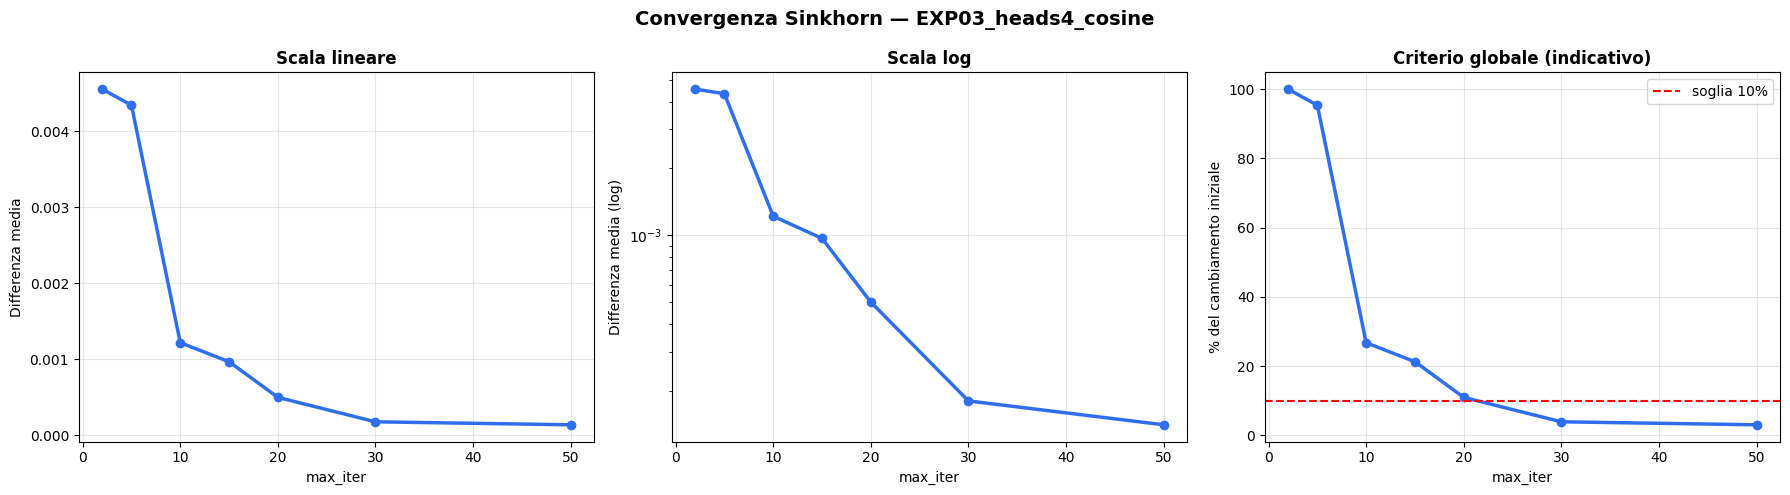

In [37]:
mi_vals = max_iter_values[1:]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(mi_vals, [res_exp03["deltas"][mi] for mi in mi_vals], marker='o', linewidth=2.5, color='#2f6fed')
axes[0].set_xlabel("max_iter"); axes[0].set_ylabel("Differenza media"); axes[0].set_title("Scala lineare", fontweight='bold'); axes[0].grid(alpha=0.3)

axes[1].plot(mi_vals, [res_exp03["deltas"][mi] for mi in mi_vals], marker='o', linewidth=2.5, color='#2f6fed')
axes[1].set_yscale('log'); axes[1].set_xlabel("max_iter"); axes[1].set_ylabel("Differenza media (log)"); axes[1].set_title("Scala log", fontweight='bold'); axes[1].grid(alpha=0.3)

threshold = 10
axes[2].plot(mi_vals, [res_exp03["deltas_pct"][mi] for mi in mi_vals], marker='o', linewidth=2.5, color='#2f6fed')
axes[2].axhline(y=threshold, color='red', linestyle='--', label=f'soglia {threshold}%')
axes[2].set_xlabel("max_iter"); axes[2].set_ylabel("% del cambiamento iniziale"); axes[2].set_title("Criterio globale (indicativo)", fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("Convergenza Sinkhorn — EXP03_heads4_cosine", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("convergenza_sinkhorn_exp03.png", dpi=150)
plt.show()

**Stabilità dell'argmax per tipo di nodo, al variare di max_iter** — percentuale di colonne che cambiano decisione finale rispetto a max_iter=100, separata per room e wall-surface.


  max_iter |     room |       ws
         2 |  17.500% |   1.682%
         5 |  13.333% |   1.308%
        10 |   6.667% |   0.374%
        15 |   6.667% |   0.187%
        20 |   5.000% |   0.187%
        30 |   3.333% |   0.000%
        50 |   3.333% |   0.000%


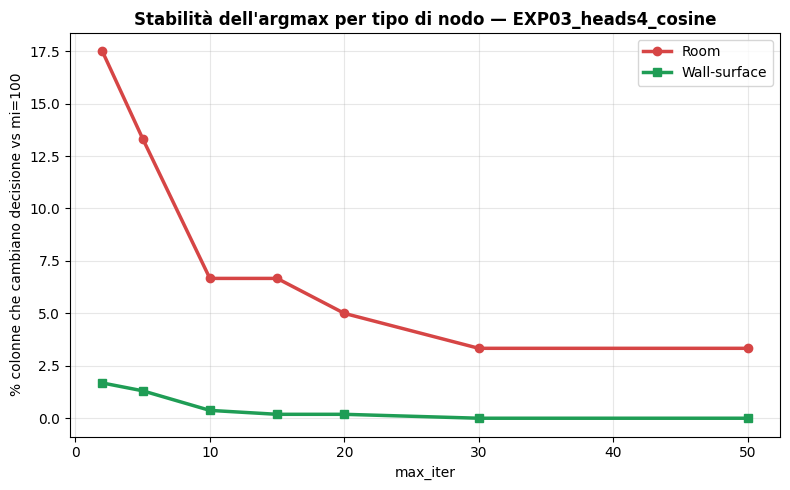

In [38]:
full_results = check_disagreement_by_type_full(model, exp03_path, sample_graphs, max_iter_values[1:])

print(f"{'max_iter':>10} | {'room':>8} | {'ws':>8}")
for mi in max_iter_values[1:]:
    print(f"{mi:>10} | {full_results[mi]['room_pct']:>7.3f}% | {full_results[mi]['ws_pct']:>7.3f}%")

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(max_iter_values[1:], [full_results[mi]["room_pct"] for mi in max_iter_values[1:]], marker='o', linewidth=2.5, label='Room', color='#d64545')
ax.plot(max_iter_values[1:], [full_results[mi]["ws_pct"] for mi in max_iter_values[1:]], marker='s', linewidth=2.5, label='Wall-surface', color='#1f9d55')
ax.set_xlabel("max_iter"); ax.set_ylabel("% colonne che cambiano decisione vs mi=100")
ax.set_title("Stabilità dell'argmax per tipo di nodo — EXP03_heads4_cosine", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stabilita_argmax_per_tipo_exp03.png", dpi=150)
plt.show()

## TAU — EXP06_heads4_cosine_wbce_maxiter30


In [ ]:
checkpoint = torch.load(os.path.join(models_path, "EXP06_heads4_cosine_wbce_maxiter30", "best_val_model.pt"), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
model.eval()

tau_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]   
sample_graphs = test_list[:100] 

results_tau = {}
for t in tau_values:
    model.sinkhorn_tau = t
    metrics_hung = evaluate_test_metrics(model, sample_graphs, use_hungarian=True)
    m = compute_extended_metrics(model, sample_graphs)
    results_tau[t] = {
        "f1_global": m["hung_f1_global"],
        "f1_room": m["hung_f1_room"],
        "f1_ws": m["hung_f1_ws"],
    }

print(f"{'tau':>6} | {'F1 globale':>10} | {'F1 room':>10} | {'F1 ws':>10}")
for t in tau_values:
    r = results_tau[t]
    print(f"{t:>6} | {r['f1_global']:>10.4f} | {r['f1_room']:>10.4f} | {r['f1_ws']:>10.4f}")

   tau | F1 globale |    F1 room |      F1 ws
   0.3 |     0.9032 |     0.7874 |     0.9284
   0.5 |     0.8994 |     0.7664 |     0.9284
   0.7 |     0.8994 |     0.7664 |     0.9284
   1.0 |     0.9013 |     0.7664 |     0.9307
   1.5 |     0.8994 |     0.7559 |     0.9307
   2.0 |     0.8985 |     0.7480 |     0.9313


**Sensibilità di F1 al variare di tau (checkpoint EXP06, solo inferenza)** — F1 globale/room/wall-surface per diversi valori della temperatura di Sinkhorn, con riferimento al tau nativo (1.0).


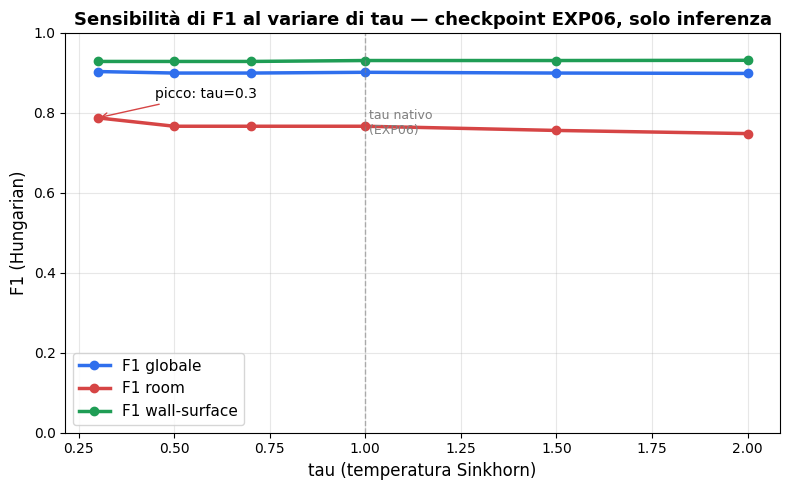

In [24]:
import matplotlib.pyplot as plt

tau_vals = tau_values  # quelli già usati nello sweep
f1_global = [results_tau[t]["f1_global"] for t in tau_vals]
f1_room   = [results_tau[t]["f1_room"] for t in tau_vals]
f1_ws     = [results_tau[t]["f1_ws"] for t in tau_vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau_vals, f1_global, marker='o', linewidth=2.5, label='F1 globale', color='#2f6fed')
ax.plot(tau_vals, f1_room, marker='o', linewidth=2.5, label='F1 room', color='#d64545')
ax.plot(tau_vals, f1_ws, marker='o', linewidth=2.5, label='F1 wall-surface', color='#1f9d55')

# linea verticale sul valore nativo di EXP06, per riferimento
ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(1.0, ax.get_ylim()[0], ' tau nativo\n (EXP06)', fontsize=9, color='gray', va='bottom')

# annotazione sul picco di F1 room
best_tau = tau_vals[f1_room.index(max(f1_room))]
ax.annotate(f'picco: tau={best_tau}',
            xy=(best_tau, max(f1_room)),
            xytext=(best_tau + 0.15, max(f1_room) + 0.05),
            arrowprops=dict(arrowstyle='->', color='#d64545'))

ax.set_xlabel("tau (temperatura Sinkhorn)", fontsize=12)
ax.set_ylabel("F1 (Hungarian)", fontsize=12)
ax.set_title("Sensibilità di F1 al variare di tau — checkpoint EXP06, solo inferenza", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("tau_sweep_f1_per_tipo.png", dpi=300)  # 300 dpi, qualità da report/stampa
plt.show()

**Impatto percentuale di tau su F1 room, rispetto a tau=1.0** — stessa analisi della cella precedente, espressa come variazione percentuale per evidenziare l'entità dell'effetto.


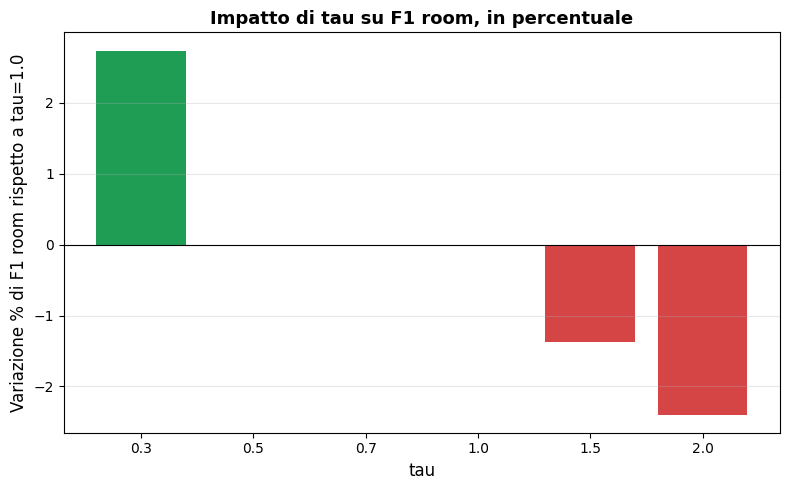

In [25]:
baseline_room = results_tau[1.0]["f1_room"]
variation_pct = [(results_tau[t]["f1_room"] - baseline_room) / baseline_room * 100 for t in tau_vals]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1f9d55' if v >= 0 else '#d64545' for v in variation_pct]
ax.bar([str(t) for t in tau_vals], variation_pct, color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel("tau", fontsize=12)
ax.set_ylabel("Variazione % di F1 room rispetto a tau=1.0", fontsize=12)
ax.set_title("Impatto di tau su F1 room, in percentuale", fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("tau_sweep_variazione_pct.png", dpi=300)
plt.show()